In [2]:
# Ran with predictors_simple kernel
# Python 3.10.8

import numpy as np # 1.26.4
import pandas as pd # 2.2.3
import tensorflow as tf # 2.10.0
import matplotlib # 3.10.3
import torch # 2.0.0

matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['font.sans-serif'] = 'Arial'
from matplotlib import pyplot as plt

from joblib import load
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.metrics import auc
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec
import seaborn as sns
import re

import os

from analysis_functions import get_best_model, get_conv_weights, get_linear_weights, load_two_state_model, make_row_plot, make_row_plot_abund

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction/Model")
from ADModel_three_state import ADModel_three_state_abund
from ADModel_two_state import ADModel_two_state_abund
from Data import DataReader, SplitData, FastTensorDataLoader, one_hot_encode


os.chdir("/Users/claireleblanc/Documents/tools_software/adhunter")
from actpred.models import ActCNNSystem

# Set Numpy to display floats with 3 decimal places
np.set_printoptions(formatter={'float': lambda x: "{0:0.3f}".format(x)})

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction")

In [3]:
# Parameters to make figures work better with illustrator 
import matplotlib 
# For higher resoltion figures
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

In [4]:
# These are the data files used in trainning
val_seqs = pd.read_csv("Data/Faure_paper/PSD95_PDZ3_Faure_data_wrangled_validation.csv")
train_seqs = pd.read_csv("Data/Faure_paper/PSD95_PDZ3_Faure_data_wrangled_training.csv")
test_seqs = pd.read_csv("Data/Faure_paper/PSD95_PDZ3_Faure_data_wrangled_test.csv")


In [5]:
two_model_results = pd.read_csv("results/PSD95_PDZ3_Faure_results_two_state_test_leakyReLU.csv")
get_best_model(two_model_results, spearman_abund=True).iloc[0]['model_name']

'../../model_data/Faure_two_state_abundmodel_b10_e200_L0.001_sMinMax_aHill_c1_k84_ak84_LeakyReLU_0.1PosKLoss_0PosWeightLoss_hSplit_hv1_seed1834636_weightInit'

In [6]:
name = get_best_model(two_model_results, spearman_abund=True, pearson_abund=True).iloc[0]['model_name'] 

In [7]:
# For two state model:
# This is an attempt to choose the "best" model in an unbiased way
# Specifically, it tries to choose a model that has both a high pearson and a high spearman correlation
# It does this by choosing the model with the highest combined spearman and pearson rank

two_model_results = pd.read_csv("results/PSD95_PDZ3_Faure_results_two_state_test_leakyReLU.csv")
two_model_results = two_model_results[["noEarlyStopping" not in n for n in two_model_results['model_name']]]

two_model_results = get_best_model(two_model_results, spearman_abund=True, pearson_abund=True)

In [9]:
# Running the two-state biophysical model on the data

# Biophysical model parameters
size = (1,84,20)
hill_value = 1
relu = False
outchannel = 1

# Loading the "best" model, as defined above based on val data
# We also are filtering to use Hill value as that gave systematically better pearson correlations
best_two_model_row = two_model_results[(two_model_results['activity_fun'] == "Hill") & (two_model_results['spearman_act_val'] > 0.85) & (two_model_results['spearman_abund_val'] > 0.85) & (two_model_results['pearson_act_val'] > 0.85) & (two_model_results['pearson_abund_val'] > 0.8)].sort_values(["max_rank","sum_rank"]).reset_index()
# best_two_model_row = pd.DataFrame(two_model_results.loc[23]).T.reset_index()
model = best_two_model_row.loc[0, "model_name"].removeprefix("../../")
kernel_size_two = best_two_model_row.loc[0, "kernel_size"]
abund_k_two = int(re.search(r'ak(\d+)',model).group(1))
activity_fun = best_two_model_row.loc[0, "activity_fun"]
best_params = best_two_model_row.loc[0, "total_params"]

two_state_biophysical_model = ADModel_two_state_abund(size,activity_fun, kernel_size_two, relu=False, abund_k=abund_k_two)
two_state_biophysical_model.load_state_dict(torch.load(f"{model}.pth"))

two_state_biophysical_model.eval()

# Loading the scaler
sc_act = load("scripts/trainning_scripts/Faure_scaler_activity.bin")
sc_abund = load("scripts/trainning_scripts/Faure_scaler_abund.bin")


def run_biophysical_model(loaded_model,sequence):
    """
    Takes a sequence and run the model on sequence
    """
    encoded_seq = one_hot_encode(sequence).reshape(1,1,84,20)
    seq_tensor = torch.from_numpy(encoded_seq).type(torch.FloatTensor)
    predictions = loaded_model(seq_tensor)
    predictions_act = sc_act.inverse_transform(predictions.detach().numpy().reshape(-1)[1].reshape(1,-1))
    predictions_abund = sc_abund.inverse_transform(predictions.detach().numpy().reshape(-1)[0].reshape(1,-1))
    K = two_state_biophysical_model.get_ks()[0].detach().numpy()[0][0]
    return predictions_abund, predictions_act, K

# Run biophysical model on all the sequences
test_seqs["biophysics_gfp_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[1][0][0] for tile in test_seqs["aa_seq"]]
test_seqs["K1"] = [run_biophysical_model(two_state_biophysical_model, tile)[2] for tile in test_seqs["aa_seq"]]

val_seqs["biophysics_gfp_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[1][0][0] for tile in val_seqs["aa_seq"]]
val_seqs["K1"] = [run_biophysical_model(two_state_biophysical_model, tile)[2] for tile in val_seqs["aa_seq"]]

train_seqs["biophysics_gfp_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[1][0][0] for tile in train_seqs["aa_seq"]]
train_seqs["K1"] = [run_biophysical_model(two_state_biophysical_model, tile)[2] for tile in train_seqs["aa_seq"]]


test_seqs["biophysics_mcherry_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[0][0][0] for tile in test_seqs["aa_seq"]]
val_seqs["biophysics_mcherry_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[0][0][0] for tile in val_seqs["aa_seq"]]
train_seqs["biophysics_mcherry_pred_2"] = [run_biophysical_model(two_state_biophysical_model, tile)[0][0][0] for tile in train_seqs["aa_seq"]]


# Evaluating model performance

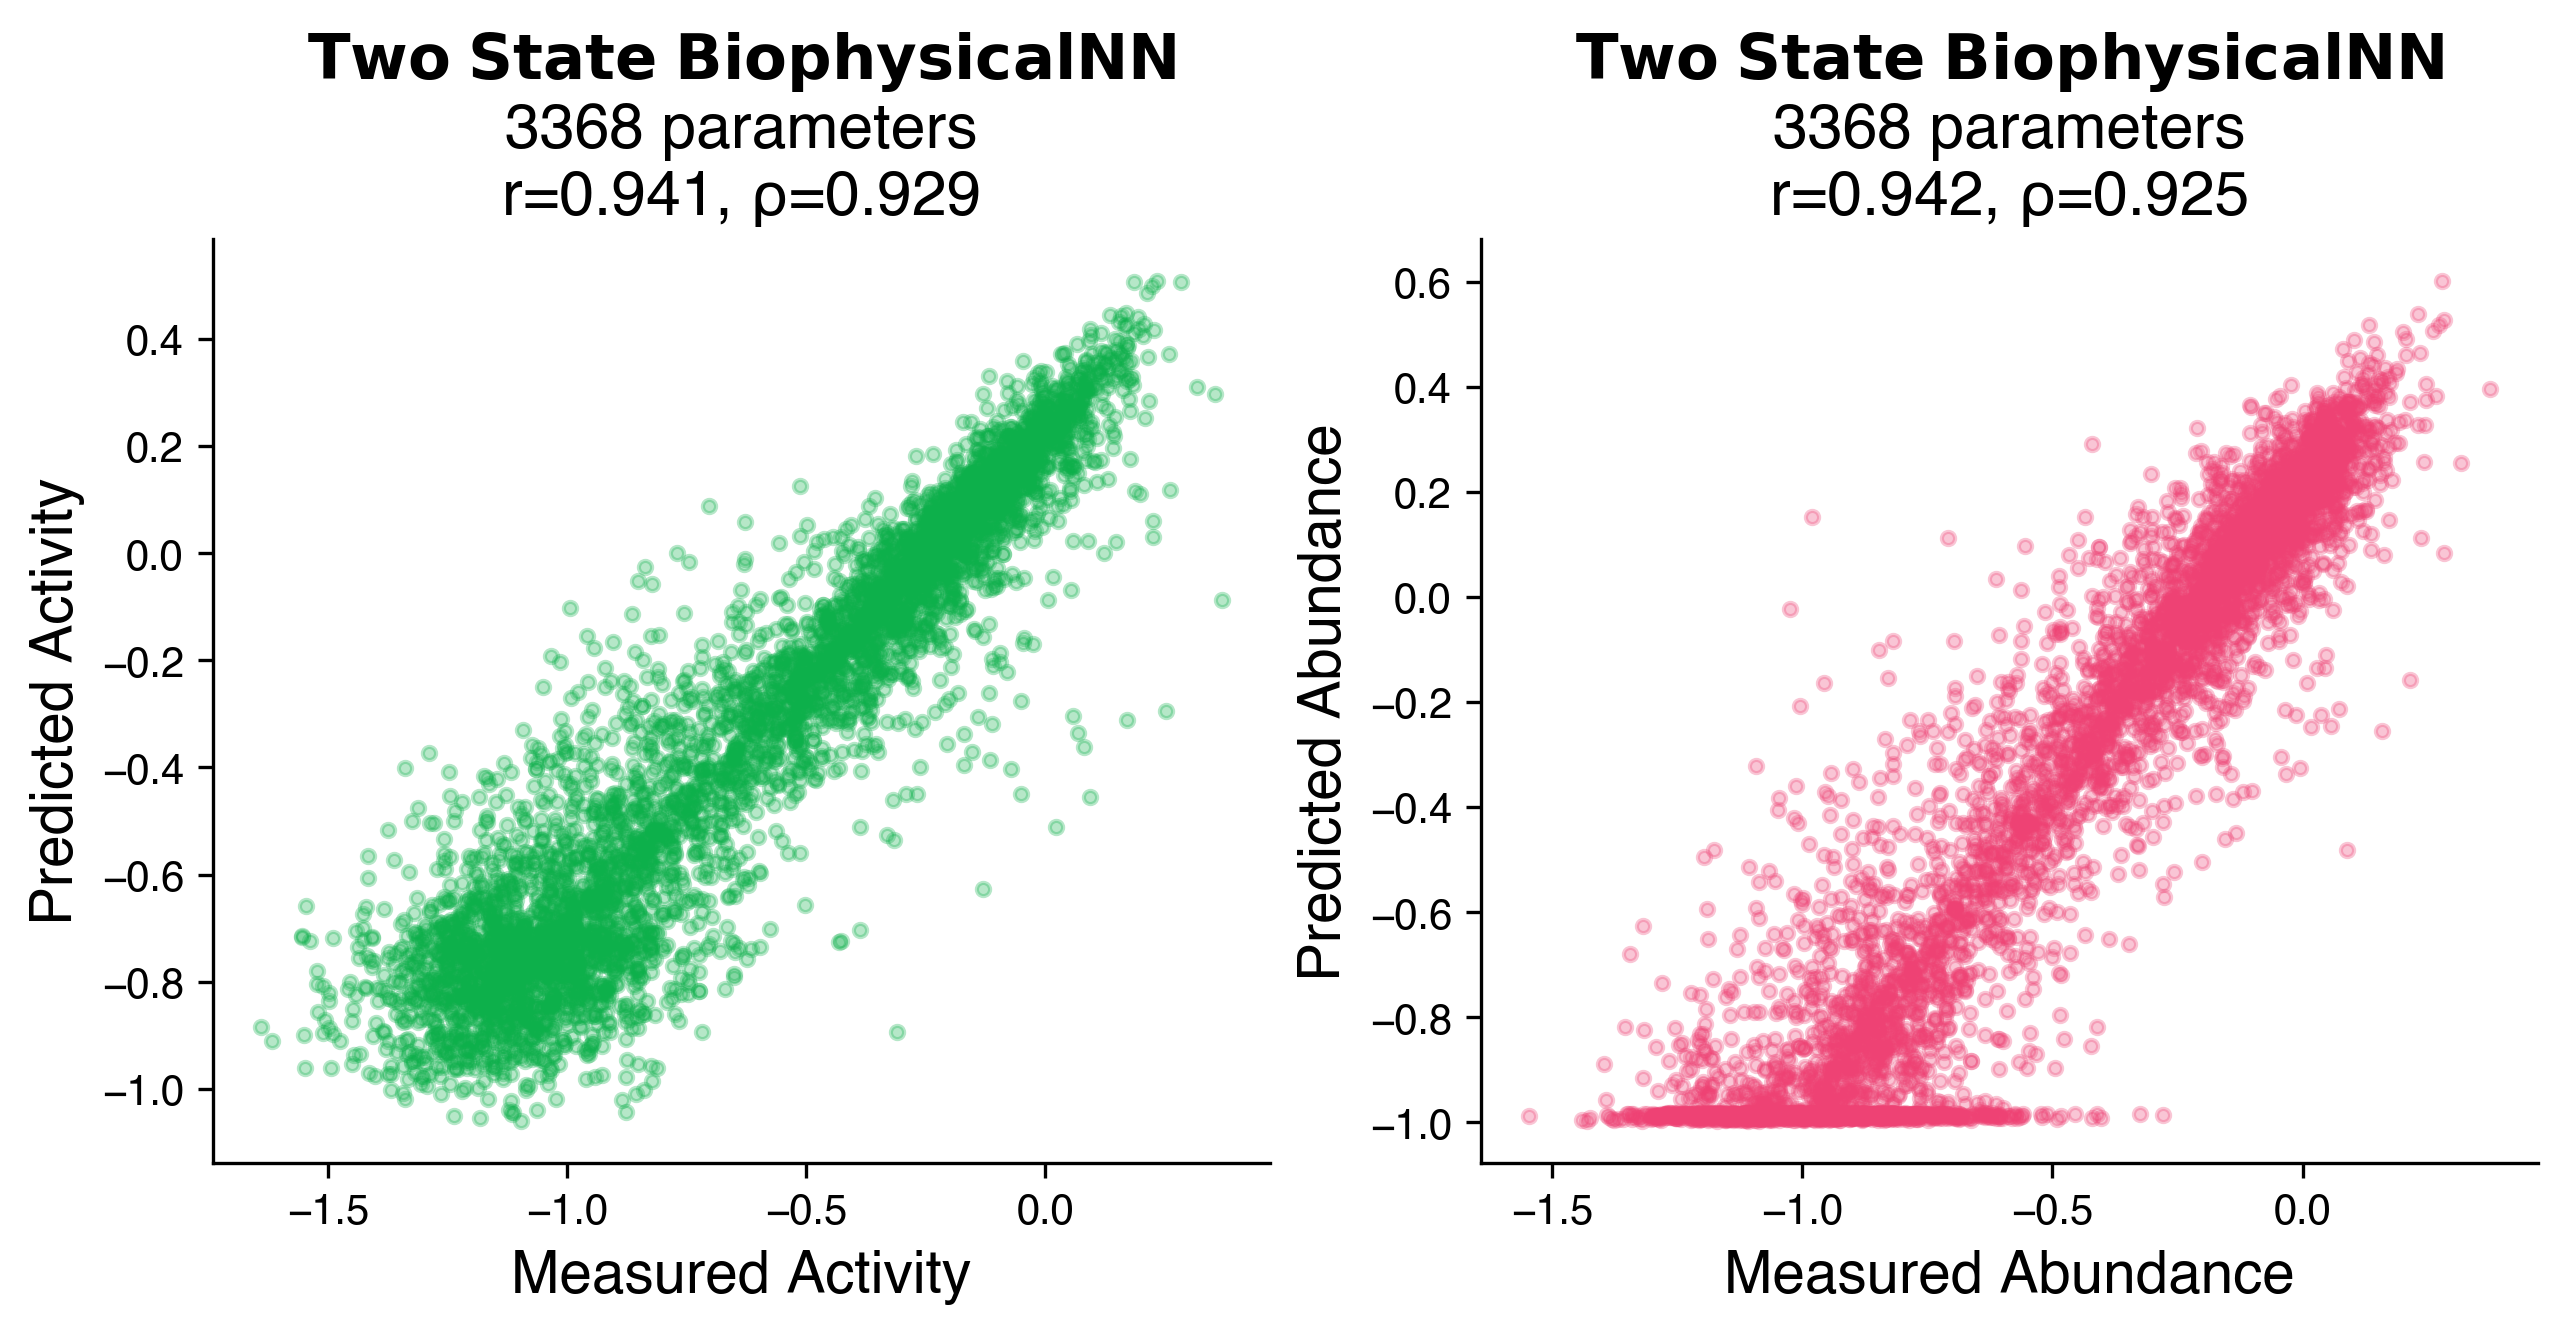

In [7]:
# Code to plot scatter plots for two-state BiophysicalNN, and ADHunter

fig, axs = plt.subplots(1,2,figsize=(10,4))

# Scatter plot for two-state BiophysicalNN - GFP
# tiles = [i for ls in test_seqs["40_tiles"] for i in ls]
# tiles = tiles + (list(other_tiles["aa_seq"]))
# actual = [i for ls in test_seqs["40_tiles_exp_activities"] for i in ls]
# actual = actual + (list(other_tiles["activity"]))
# pred = [i for ls in test_seqs["biophysics_gfp_pred_2"] for i in ls]
# pred = pred + (list(other_tiles["biophysics_gfp_pred_2"]))
plotting_data = train_seqs[['activity', 'biophysics_gfp_pred_2', 'aa_seq']]
plotting_data = plotting_data.dropna()
plotting_data.columns = ["actual", "pred", "aa_seq"]
plotting_data = plotting_data.drop_duplicates("aa_seq") 

axs[0].scatter(plotting_data['actual'], plotting_data['pred'], color='#0DB04B', s=10, alpha=0.3)
spearman = spearmanr(plotting_data["actual"], plotting_data["pred"]).correlation
pearson = pearsonr(plotting_data["actual"].astype('float'), plotting_data["pred"].astype('float')).correlation#np.corrcoef(list(plotting_data["actual"].values), list(plotting_data["pred"].values))[0, 1] ** 2
axs[0].set_xlabel('Measured Activity', fontsize=14)
axs[0].set_ylabel('Predicted Activity', fontsize=14)
axs[0].set_title(r"$\bf{Two}$ $\bf{State}$ $\bf{BiophysicalNN}$" + f'\n{best_params} parameters\nr={pearson:.3}, \u03C1={spearman:.3}', fontsize=15)

# Scatter plot for two-state BiophysicalNN - mCherry
# tiles = [i for ls in test_seqs["40_tiles"] for i in ls]
# tiles = tiles + (list(other_tiles["aa_seq"]))
# actual = [i for ls in test_seqs["40_tiles_exp_abundance"] for i in ls]
# actual = actual + (list(other_tiles["abundance"]))
# pred = [i for ls in test_seqs["biophysics_mcherry_pred_2"] for i in ls]
# pred = pred + (list(other_tiles["biophysics_mcherry_pred_2"]))
plotting_data = train_seqs[['abundance', 'biophysics_mcherry_pred_2', 'aa_seq']]
plotting_data = plotting_data.dropna()
plotting_data.columns = ["actual", "pred", "aa_seq"]
plotting_data = plotting_data.drop_duplicates("aa_seq") 

axs[1].scatter(plotting_data['actual'], plotting_data['pred'], color='#EE4274', s=10, alpha=0.3)
spearman = spearmanr(plotting_data["actual"], plotting_data["pred"]).correlation
pearson = pearsonr(plotting_data["actual"].astype('float'), plotting_data["pred"].astype('float')).correlation#np.corrcoef(list(plotting_data["actual"].values), list(plotting_data["pred"].values))[0, 1] ** 2
axs[1].set_xlabel('Measured Abundance', fontsize=14)
axs[1].set_ylabel('Predicted Abundance', fontsize=14)
axs[1].set_title(r"$\bf{Two}$ $\bf{State}$ $\bf{BiophysicalNN}$" + f'\n{best_params} parameters\nr={pearson:.3}, \u03C1={spearman:.3}', fontsize=15)

sns.despine()
# plt.savefig("figures/PDZ3_two_state_scatter_plots.pdf", format='pdf', bbox_inches='tight')

# Inspecting the parameters of the two-state BiophysicalNN

In [15]:
# Order of AAs for plotting
amino_acids = ["R","K","H","D","E","M","I","L","V","A","F","Y","W","Q","N","S","T","G","P","C"]

def get_conv_weights(model, layer): 
    """
    Extracts the convolutional layer weights and
    returns them as a pandas dataframe
    """
    model_state_dict = model.state_dict()
    width = model_state_dict[layer].shape[0] * model_state_dict[layer].shape[2]
    conv_weight = model_state_dict[layer].detach().numpy().reshape(width,20)
    conv_weights = pd.DataFrame(conv_weight,columns = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"])
    conv_weights = conv_weights[amino_acids]
    return conv_weights

def get_linear_weights(model, layer, kernel_size):
    """
    Extracts the linear layer weights and
    returns them as a numpy array. Also returns the 
    corresponding x-axis values
    """
    linear_weights = (84 - kernel_size + 1)
    model_state_dict = model.state_dict()
    linear_weight = model_state_dict[layer].detach().numpy().reshape(linear_weights)
    x_vals = np.array(range(0,linear_weights))
    return linear_weight, x_vals


In [512]:
# This is setting up our colors for the plots

# Colors for convolutional filter
colors = [(1, 0, 0), (1, 1, 1), (0, 0, 1)]  # Red, White, Blue
n_bins = 100  # Number of color bins
cmap_name = "custom_colormap"
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
custom_cmap.set_bad(color='white', alpha=1.0)  # Handle NaN values, if any

# Colors for AA labels
colors = {'A': 'purple', 'C': 'darkorange', 'E': 'blue', 'D': 'blue', 'G': 'darkorange', 
                  'F': 'indigo', 'I': 'purple', 'H': 'green', 'K': 'green', 'M': 'purple', 
                  'L': 'purple', 'N': 'darkslategray', 'Q': 'darkslategray', 'P': 'darkorange', 'S': 'darkslategray', 
                  'R': 'green', 'T': 'darkslategray', 'W': 'indigo', 'V': 'purple', 'Y': 'indigo'}

In [513]:
def make_row_plot_abund(fig, kernel_size, model, row, lim, height_ratios, num_rows, abund_kernel_size):
    """
    Core functionality for creating the convolutional filter plots. 
    Plots the convolution filter as a heatmap and the linear weights as a bar plot.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object created with plt.figure
    
    kernel_size : int
        The size of the convolutional filter

    model : ADModel_abund
        Loaded model (from which parameters will be extracted)
    
    row : int
        Which row in the overall figure should we fill in

    lim : float
        The max value for the heatmap

    height_ratios : list
        Ratio of heights between rows, length should correspond to number of rows in
        gridspec object

    num_rows : list
        The number of rows in the gridspec object

    Returns
    -------
    ax1 : maplotlib.Axes object
        Contains the heatmap
    ax2 : maplotlib.Axes object
        Contains the barplot
    im1 : maplotlib.Axes.imshow object
        The heatmap
    """

    # Load the convolutional and linear weights for both NN blocks
    model_conv1 = get_conv_weights(model, "conv1.weight").T
    model_linear1, model_xvals1 = get_linear_weights(model, "linear1.weight", kernel_size)

    model_conv2 = get_conv_weights(model, "conv2.weight").T
    model_linear2, model_xvals2 = get_linear_weights(model, "linear2.weight", abund_kernel_size)

    # Calculate how much of the figure the convolutional filters vs. linear weights will take up
    ratio1 = kernel_size 
    ratio2 = 84 - kernel_size + 1
    ratio1_abund = abund_kernel_size
    ratio2_abund = 84 - abund_kernel_size + 1

    # GridSpec allows us to plot rows/columns with different dimensions
    # Here, we initalize the gridspec object with the total number of rows in our figure
    # But we only fill in the specific row that we are interested in
    # (When combined with many other gridspec objects, they will all line up and look good)
    gs1 = gridspec.GridSpec(2 + num_rows, 5, width_ratios=[ratio1, ratio2, 0.5, ratio1_abund, ratio2_abund], height_ratios=height_ratios, figure=fig)
    
    # axs are matplotlib axes
    ax1 = plt.subplot(gs1[row, 0])
    ax2 = plt.subplot(gs1[row, 1])
    ax3 = plt.subplot(gs1[row, 3])
    ax4 = plt.subplot(gs1[row, 4])


    ## Code for first set of parameters --> K1 predictor
    # This is the code for plotting the convolutional filter as a heatmap
    # Min and max values of heatmap are passed by used
    im1 = ax1.imshow(model_conv1.to_numpy(), cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    ax1.set_yticks(range(len(model_conv1.index)), model_conv1.index)  # Label x-axis with column names
    ax1.set_xticks(np.arange(kernel_size, step=2))

    # This is to color the amino acid labels
    for ytic in ax1.get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])
    ax1.tick_params(axis='both', which='major', labelsize=6) 

    # This is the code for plotting the linear weights as a bar graph
    ax2.bar(model_xvals1, model_linear1, color="grey")
    ax2.spines["top"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["bottom"].set_position('zero')
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_xticklabels([])
    ax2.set_yticklabels([])

    ## Code for second set of parameters --> abundance predictor
    # This is the code for plotting the convolutional filter as a heatmap
    # Min and max values of heatmap are passed by used
    im2 = ax3.imshow(model_conv2.to_numpy(), cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    ax3.set_yticks(range(len(model_conv2.index)), model_conv2.index)  # Label x-axis with column names
    ax3.set_xticks(np.arange(abund_kernel_size, step=2))
    
    # This is to color the amino acid labels
    for ytic in ax3.get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])
    ax3.tick_params(axis='both', which='major', labelsize=6) 

    # This is the code for plotting the linear weights as a bar graph
    print(model_xvals2, model_linear2)
    ax4.bar(model_xvals2, model_linear2, color="grey")
    ax4.spines["top"].set_visible(False)
    ax4.spines["left"].set_visible(False)
    ax4.spines["right"].set_visible(False)
    ax4.spines["bottom"].set_position('zero')
    ax4.set_xticks([])
    ax4.set_yticks([])
    ax4.set_xticklabels([])
    ax4.set_yticklabels([])


    return ax1, ax2, ax3, ax4, im1, im2


[0] [0.606]


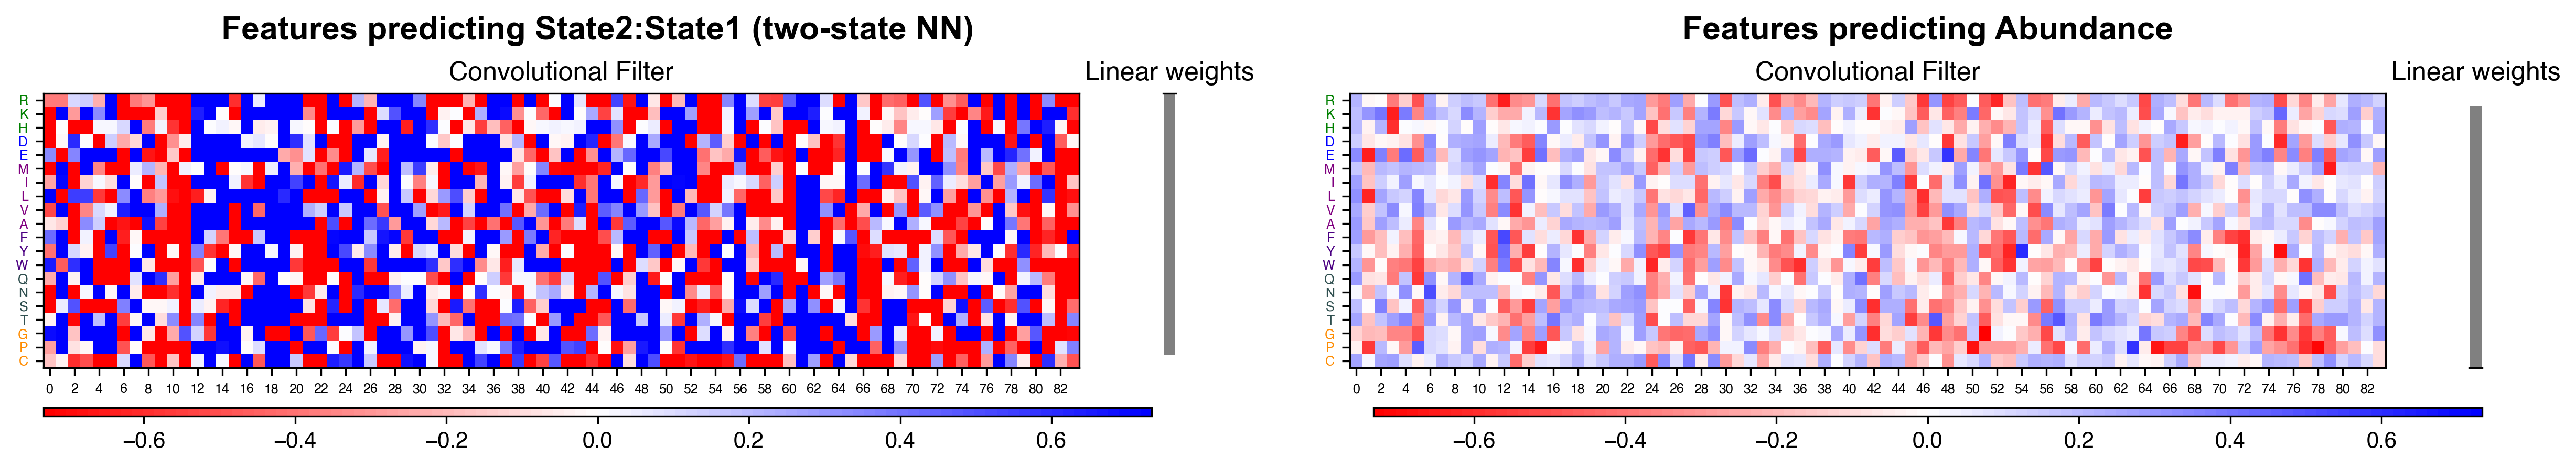

In [10]:
# Get the range for the heatmaps
models = [two_state_biophysical_model]
conv_weights = []

for model in models: 
    # conv_weights += list(get_conv_weights(model, "conv1.weight").T.values.flatten())
    conv_weights += list(get_conv_weights(model, "conv2.weight").T.values.flatten())

# Max value for heatmaps
lim = max([abs(w) for w in conv_weights])

num_rows = 1

# Create a figure
fig = plt.figure(figsize=(20, 3*num_rows))
title_font = {'fontsize': 15, 'fontweight': 'bold', 'fontname': 'Arial'}

# We add in "padding" rows between the rows we care about
height_ratios = [.3] + [3.3]*num_rows + [.1]*2

# Create a gridspec object
gs1 = gridspec.GridSpec(3 + num_rows, 2, width_ratios=[1,1], height_ratios=height_ratios, figure=fig)

# Making the first row a title row
ax1 = plt.subplot(gs1[0,0])
ax1.set_title("Features predicting State2:State1 (two-state NN)", fontdict=title_font)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.patch.set_visible(False)
ax1.axis('off')

ax2 = plt.subplot(gs1[0,1])
ax2.set_title("Features predicting Abundance", fontdict=title_font)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.patch.set_visible(False)
ax2.axis('off')

# Adding the best NN parameters to the first row
ax1, ax2, ax3, ax4, im1, im2 = make_row_plot_abund(fig, kernel_size_two, two_state_biophysical_model, 1, lim, height_ratios, num_rows+1, abund_k_two, max_width=84)

ax1.set_title("Convolutional Filter", fontsize=12)
ax2.set_title("Linear weights", fontsize=12)
ax3.set_title("Convolutional Filter", fontsize=12)
ax4.set_title("Linear weights", fontsize=12)

# Create another gridspec object to span the whole figure (1 column) to display the colorbar
gs_cb = gridspec.GridSpec(3 + num_rows, 2, width_ratios=[1,1], height_ratios=height_ratios, figure=fig)
cax1 = plt.subplot(gs_cb[2 + num_rows, 0])
cax2 = plt.subplot(gs_cb[2 + num_rows, 1])

# Add the colorbar
fig.colorbar(im1,cax=cax1, orientation='horizontal')
fig.colorbar(im2, cax=cax2, orientation='horizontal')

# plt.savefig('figures/PSD95_two_state_parameters_abund_scale.pdf', dpi=1000, bbox_inches='tight')

[0] [0.606]


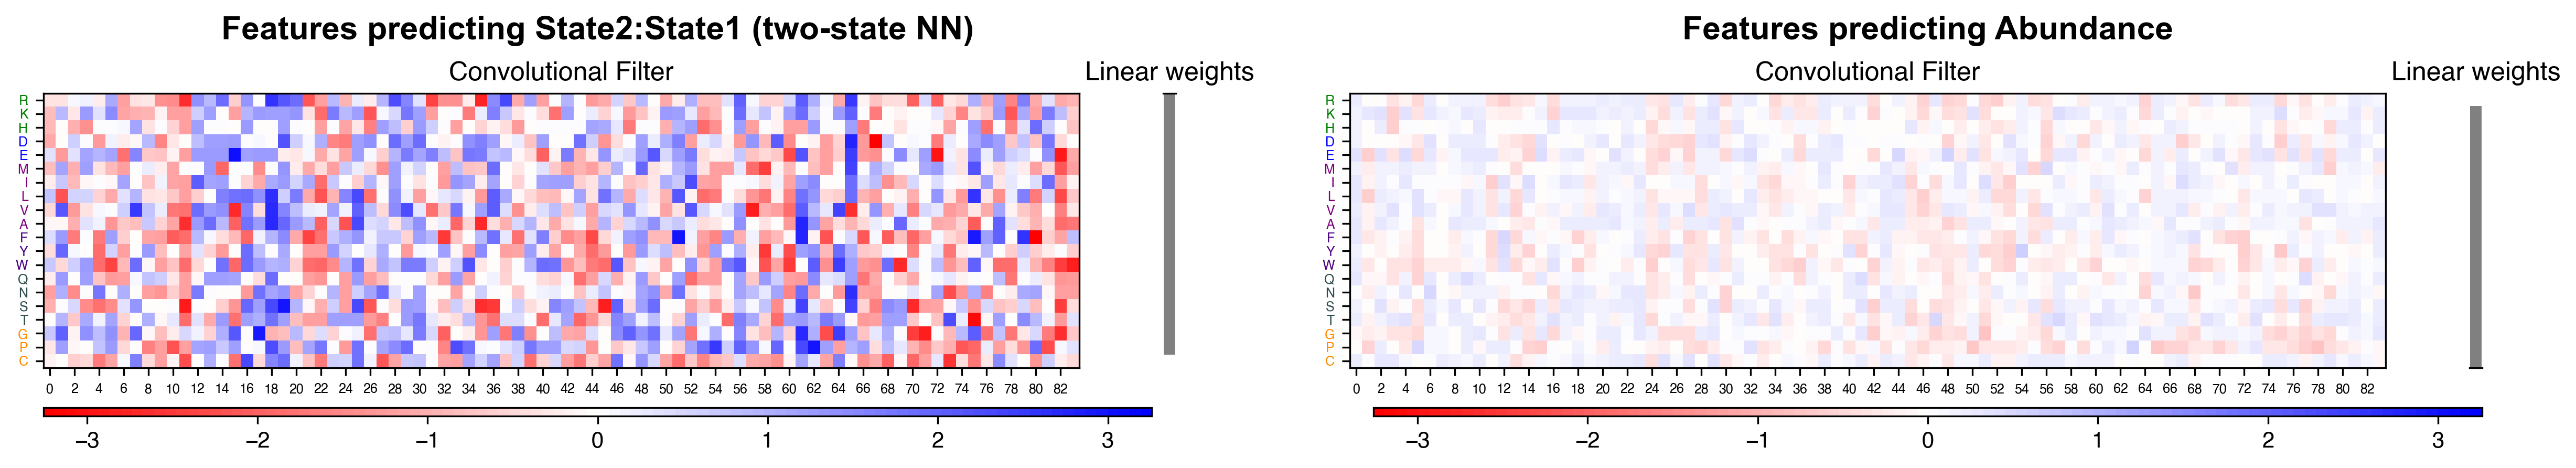

In [11]:
# Get the range for the heatmaps
models = [two_state_biophysical_model]
conv_weights = []

for model in models: 
    conv_weights += list(get_conv_weights(model, "conv1.weight").T.values.flatten())
    # conv_weights += list(get_conv_weights(model, "conv2.weight").T.values.flatten())

# Max value for heatmaps
lim = max([abs(w) for w in conv_weights])

num_rows = 1

# Create a figure
fig = plt.figure(figsize=(20, 3*num_rows))
title_font = {'fontsize': 15, 'fontweight': 'bold', 'fontname': 'Arial'}

# We add in "padding" rows between the rows we care about
height_ratios = [.3] + [3.3]*num_rows + [.1]*2

# Create a gridspec object
gs1 = gridspec.GridSpec(3 + num_rows, 2, width_ratios=[1,1], height_ratios=height_ratios, figure=fig)

# Making the first row a title row
ax1 = plt.subplot(gs1[0,0])
ax1.set_title("Features predicting State2:State1 (two-state NN)", fontdict=title_font)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.patch.set_visible(False)
ax1.axis('off')

ax2 = plt.subplot(gs1[0,1])
ax2.set_title("Features predicting Abundance", fontdict=title_font)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.patch.set_visible(False)
ax2.axis('off')

# Adding the best NN parameters to the first row
ax1, ax2, ax3, ax4, im1, im2 = make_row_plot_abund(fig, kernel_size_two, two_state_biophysical_model, 1, lim, height_ratios, num_rows+1, abund_k_two, max_width=84)

ax1.set_title("Convolutional Filter", fontsize=12)
ax2.set_title("Linear weights", fontsize=12)
ax3.set_title("Convolutional Filter", fontsize=12)
ax4.set_title("Linear weights", fontsize=12)

# Create another gridspec object to span the whole figure (1 column) to display the colorbar
gs_cb = gridspec.GridSpec(3 + num_rows, 2, width_ratios=[1,1], height_ratios=height_ratios, figure=fig)
cax1 = plt.subplot(gs_cb[2 + num_rows, 0])
cax2 = plt.subplot(gs_cb[2 + num_rows, 1])

# Add the colorbar
fig.colorbar(im1,cax=cax1, orientation='horizontal')
fig.colorbar(im2, cax=cax2, orientation='horizontal')

# plt.savefig('figures/PSD95_two_state_parameters_bind_scale.pdf', dpi=1000, bbox_inches='tight')

# Compare with their results

In [12]:
# Our data
all_seqs = pd.concat([train_seqs, val_seqs, test_seqs])

R = 0.001987
T = 303

all_seqs['delta_G_b'] = [-R * T * np.log(K) for K in all_seqs["K1"]]

In [13]:
WT_seq = 'PRRIVIHRGSTGLGFNIVGGEDGEGIFISFILAGGPADLSGELRKGDQILSVNGVDLRNASHEQAAIALKNAGQTVTIIAQYKP'

In [14]:
# Their data
inferred_delta_G = pd.read_csv('/Users/claireleblanc/Downloads/41586_2022_4586_MOESM10_ESM.csv')
inferred_delta_G = inferred_delta_G[inferred_delta_G['protein'] == "PSD95-PDZ3"]

inferred_delta_G["aa_seq"] = [WT_seq[:int(inferred_delta_G.loc[i, 'Pos']) - 1] + inferred_delta_G.loc[i, 'Mut'] + WT_seq[int(inferred_delta_G.loc[i, 'Pos']):] if not np.isnan(inferred_delta_G.loc[i, 'Pos']) else WT_seq for i in inferred_delta_G.index]

# Missing all double mutants and sequences with no binding data
merged_data = inferred_delta_G.merge(all_seqs, on='aa_seq')
# merged_data = merged_data[merged_data['K1'] > 0]

# merged_data = merged_data[merged_data['b_ddg_pred_conf']]

PearsonRResult(statistic=0.47035135463119493, pvalue=2.1654445534823944e-68)

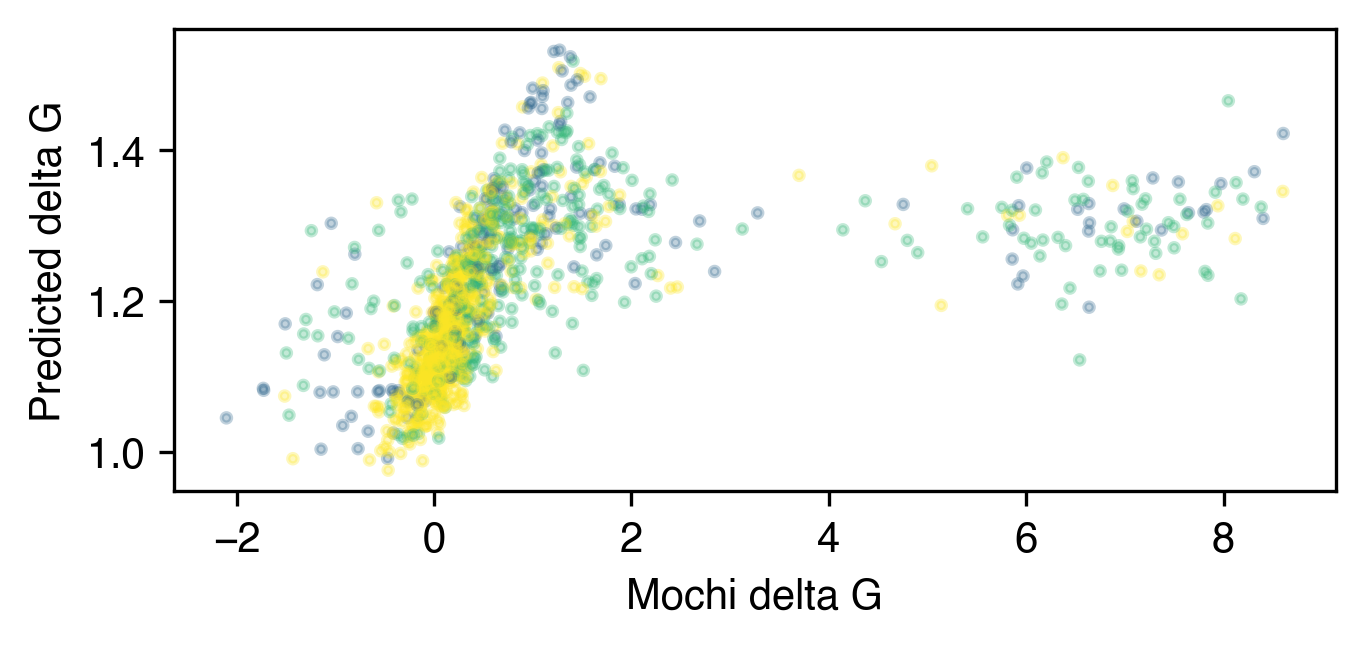

In [15]:
# For plotting calculated delta G
plt.figure(figsize=(5, 2))
merged_data_subset = merged_data #[merged_data['Pos_class'] == 'surface']
plt.scatter(merged_data_subset['b_ddg_pred'], merged_data_subset['delta_G_b'], s=5, alpha=0.3, c=merged_data_subset['Pos_class'].astype('category').cat.codes, cmap='viridis')
plt.xlabel("Mochi delta G")
plt.ylabel("Predicted delta G")
# plt.yscale('log')
pearsonr(merged_data_subset['b_ddg_pred'], np.log(merged_data_subset['K1']))
pearsonr(merged_data_subset['b_ddg_pred'], merged_data_subset['delta_G_b'])

PearsonRResult(statistic=-0.4703513565610474, pvalue=2.1654414603707906e-68)

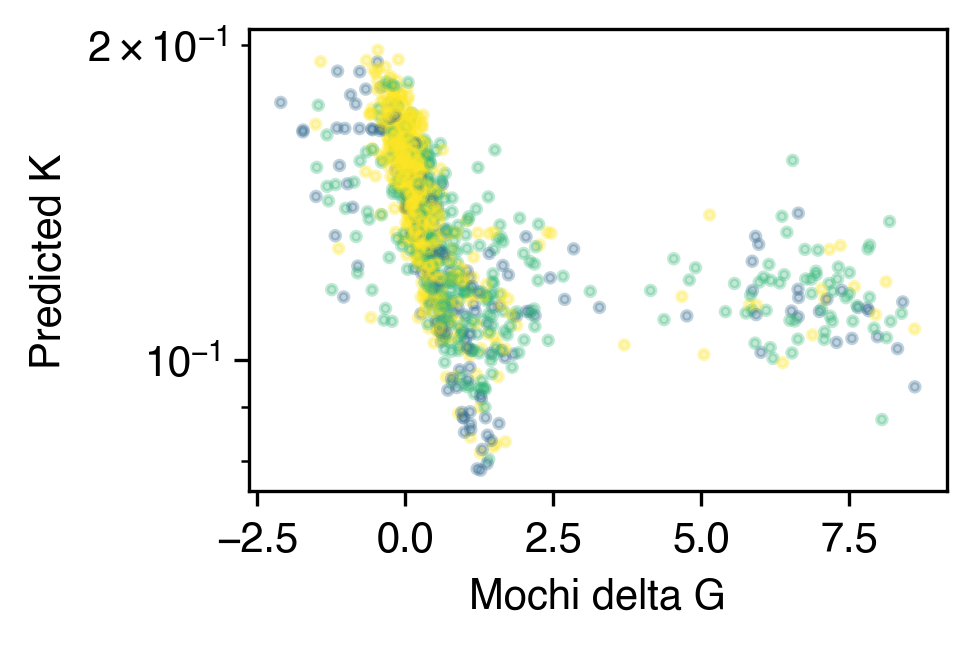

In [16]:
# For plotting K vs. G
plt.figure(figsize=(3, 2))
merged_data_subset = merged_data #[(merged_data['b_ddg_pred'] < 4)] #[merged_data['Pos_class'] == 'surface']
plt.scatter(merged_data_subset['b_ddg_pred'], merged_data_subset['K1'], s=5, alpha=0.3, c=merged_data_subset['Pos_class'].astype('category').cat.codes, cmap='viridis')
plt.xlabel("Mochi delta G")
plt.ylabel("Predicted K")
plt.yscale('log')
pearsonr(merged_data_subset['b_ddg_pred'], np.log(merged_data_subset['K1']))

# plt.xlim(-2, 3)

# plt.colorbar()
# Purple in binding interface
# Blue is core
# Yellow is sufrace
# plt.savefig('figures/PADI_two_state_parameters.pdf', dpi=1000, bbox_inches='tight')

In [17]:
# COMPARING WITH EXPERIMENTAL DATA 
experimental = pd.read_table("/Users/claireleblanc/Downloads/Data/in_vitro/PDZ_literature_free_energies.txt")
experimental['orig_AA'] = experimental['id'].str[0]
experimental['new_AA'] = experimental['id'].str[-1]
experimental['location'] = [int(re.findall("\d+", s)[0]) if s != "WT" else -1 for s in experimental['id']]
experimental["aa_seq"] = [WT_seq[:int(experimental.loc[i, 'location'] - 311)] + experimental.loc[i, 'new_AA'] + WT_seq[int(experimental.loc[i, 'location'] - 311):] if not np.isnan(experimental.loc[i, 'location']) else WT_seq for i in experimental.index]
experimental['aa_seq'] = experimental['aa_seq'].str[:-1]
experimental = experimental[experimental['Dataset'] == 'Laursen_2020']
merged_data_experimental = merged_data.merge(experimental, right_on='id', left_on='id_ref')


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


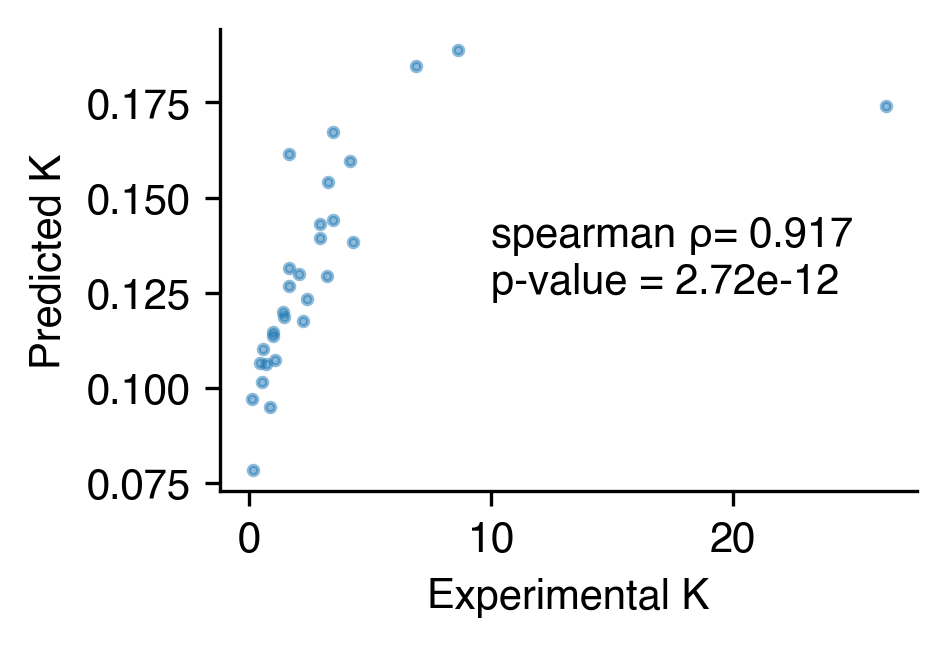

In [44]:
# For plotting K vs. G
temp_df = merged_data_experimental[['Kd', 'K1', 'Pos_class', 'b_ddg_pred_conf']].dropna()
# temp_df = temp_df[1/temp_df['Kd'] < 20]
# temp_df = temp_df[temp_df['b_ddg_pred_conf']]

plt.figure(figsize=(3, 2))
plt.scatter(1/temp_df['Kd'], temp_df['K1'], s=5, alpha=0.5) #, c=temp_df['b_ddg_pred_conf'].astype('category').cat.codes, cmap='viridis')
plt.xlabel("Experimental K")
plt.ylabel("Predicted K")

spearman_corr, spearman_p = spearmanr(1/temp_df['Kd'], temp_df['K1'])

plt.text(10, 0.125, f"spearman \u03C1= {spearman_corr:.3f}\np-value = {spearman_p:.3}")

sns.despine()
plt.savefig('figures/PSD95_experimental_corr.pdf', dpi=1000, bbox_inches='tight')


In [243]:
temp_df.sort_values('b_ddg_pred') #[temp_df['b_ddg_pred'] != 1.271178]

,Kd,b_ddg_pred,Pos_class,delta_G_b
2,0.116,-0.771006,binding_interface,-0.698338
10,0.038,-0.448110,core,-1.370241
26,0.145,-0.320173,core,-0.563992
23,0.307,-0.129117,surface,-0.112378
1,0.240,-0.128136,core,-0.260611
27,0.290,0.006846,core,-0.146675
0,0.340,0.066598,core,-0.050909
17,0.340,0.080216,surface,-0.050909
24,0.233,0.151599,surface,-0.278432
9,0.610,0.262534,surface,0.301004


SignificanceResult(statistic=0.8435096030761928, pvalue=6.255659335236237e-08)

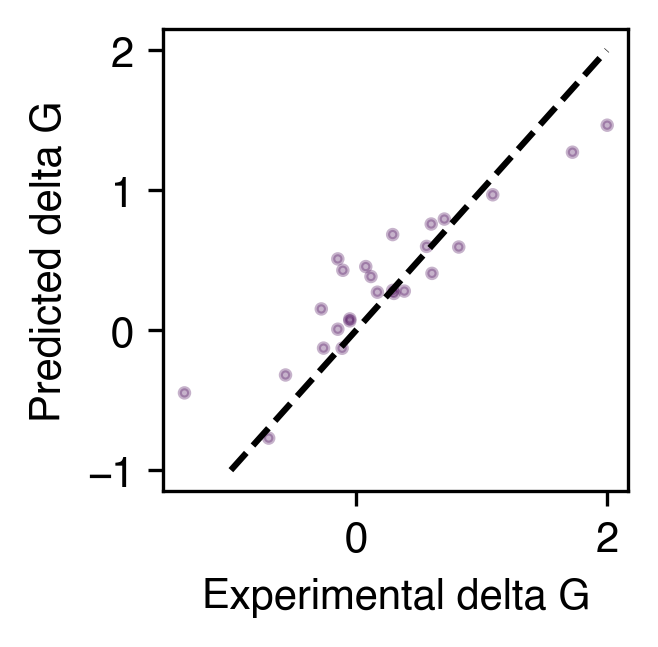

In [13]:
# For plotting K vs. G
# Here is how they filtered it (only used "confident" measurements)
temp_df = merged_data_experimental[['Kd', 'b_ddg_pred', 'Pos_class', 'b_ddg_pred_conf']].dropna()


R = 0.001987
T = 303
WT_delta_G = 0.370

temp_df['delta_G_b'] = [-R * T * np.log(WT_delta_G / K) for K in temp_df["Kd"]]
temp_df = temp_df[temp_df['b_ddg_pred_conf']]
# temp_df = temp_df[~np.isclose(temp_df['b_ddg_pred'], 1.088259)]

# temp_df = temp_df[(temp_df['delta_G_b'] > -2) &  (temp_df['b_ddg_pred'] > -1) & (temp_df['b_ddg_pred'] < 2)]

plt.figure(figsize=(2, 2))
plt.scatter(temp_df['delta_G_b'], temp_df['b_ddg_pred'], s=5, alpha=0.3, c=temp_df['b_ddg_pred_conf'].astype('category').cat.codes, cmap='viridis')
plt.xlabel("Experimental delta G")
plt.ylabel("Predicted delta G")

# plt.xlim(-1.5, 2.1)
# plt.ylim(-1, 2.1)

plt.plot([-1, 2], [-1, 2], linestyle='--', color='black')

# pearsonr(temp_df['delta_G_b'], temp_df['b_ddg_pred'])
spearmanr(temp_df['delta_G_b'], temp_df['b_ddg_pred'])


In [283]:
# Need to look at all their models to get confidence intervals
conv_weights

,R,K,H,D,E,M,I,L,V,A,F,Y,W,Q,N,S,T,G,P,C
0,-0.084340,-0.501605,-0.495906,-0.440674,0.164025,-0.344987,-0.208757,0.418192,-0.317847,-0.110469,0.126673,-0.306377,0.291836,-0.150712,-0.920041,-0.686335,0.008685,0.408267,-0.046925,-0.234413
1,-0.136914,0.486552,0.012719,-0.022299,-0.930739,0.672773,0.455755,-1.421966,1.357532,-0.135708,0.754738,1.366433,-0.333595,0.886512,0.668096,0.001978,0.648348,1.191561,0.899568,0.026716
2,0.121813,-0.190695,-0.577207,0.339555,0.228323,-0.782059,-0.321154,0.172972,-0.690224,-0.421618,-0.784408,0.206476,0.114869,-0.040344,-0.885726,0.295886,-0.672702,0.004770,0.189044,-0.408757
3,0.067595,0.915020,-0.759877,0.016452,0.526970,0.972643,-0.079946,0.273063,-0.276613,0.204088,0.045809,-0.035727,1.030856,0.931921,-0.038712,-1.061611,0.640326,0.735717,0.004500,-0.202723
4,-0.119400,0.226189,0.072969,-0.944410,0.644871,-0.259748,0.099712,-0.320223,0.065228,-0.038863,-1.099603,-1.409082,-1.331709,-0.302696,0.945073,-0.998040,-0.195096,0.332166,0.551072,-1.019436
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,1.007973,0.571227,-0.054126,0.488424,0.331832,-0.068195,0.022837,0.632283,-0.373943,-0.203782,1.667487,0.328577,0.185247,-0.030992,0.808095,0.054944,0.649804,-0.142784,-0.840137,-0.026410
80,-0.476122,-0.585634,1.093688,-0.568848,-0.165758,-0.832626,0.288882,-0.856645,-0.550561,-0.400000,-1.985523,-0.195398,-0.663004,0.127397,0.687743,-0.311196,0.604404,0.042407,1.139151,-0.588546
81,0.175734,1.044834,0.224685,0.902515,0.646864,-0.249015,1.056684,0.399034,0.019064,-0.235503,-0.203712,-0.065837,-0.787141,-0.311806,0.081713,-0.086467,-0.017031,-0.921446,-1.289937,0.186235
82,-0.590106,0.478132,0.001270,-0.740532,-1.731638,-1.163776,-0.920965,-1.476962,-0.985455,-1.002976,-0.869121,-0.013775,-1.282430,-0.835194,-0.553662,-1.635528,-0.659173,-1.517353,0.026547,-0.062284


In [55]:
# Correlation w/ main model
params = pd.read_table('/Users/claireleblanc/Downloads/Data/mochi/PSD95-PDZ3/mochi__fit_tmodel_3state_sparse_dimsum128/model_weights_0.txt')
params['orig_AA'] = params['id'].str[0]
params['new_AA'] = params['id'].str[-1]
params['location'] = [int(re.findall("\d+", s)[0]) if s != "WT" else -1 for s in params['id']]
binding_data = params.pivot(columns="location", index='new_AA', values='binding_coefficient').loc[amino_acids]

# Get correlation w/ bootstrap
conv_weights = get_conv_weights(two_state_biophysical_model, layer='conv1.weight')
our_weights = conv_weights.T.values.flatten()
their_weights = binding_data.drop(columns=[-1]).values.flatten()


df = pd.DataFrame({'ours' : our_weights, 'theirs' : their_weights}).dropna()

print(spearmanr(df['theirs'], df['ours']))


SignificanceResult(statistic=0.7103555802606969, pvalue=5.655529931380662e-241)


In [287]:
# Loop through bootstraps and look at correlations - BINDING

for i in range(1, 11):
    # Read in bootstrap params
    params = pd.read_table(f'/Users/claireleblanc/Downloads/Data/mochi/PSD95-PDZ3/mochi__fit_tmodel_3state_sparse_dimsum128/bootstrap/boot_{i}/model_weights_0.txt')
    params['orig_AA'] = params['id'].str[0]
    params['new_AA'] = params['id'].str[-1]
    params['location'] = [int(re.findall("\d+", s)[0]) if s != "WT" else -1 for s in params['id']]
    binding_data = params.pivot(columns="location", index='new_AA', values='binding_coefficient').loc[amino_acids]

    # Get correlation w/ bootstrap
    conv_weights = get_conv_weights(two_state_biophysical_model, layer='conv1.weight')

    our_weights = conv_weights.T.values.flatten()
    their_weights = binding_data.drop(columns=[-1]).values.flatten()


    df = pd.DataFrame({'ours' : our_weights, 'theirs' : their_weights}).dropna()

    print(pearsonr(df['theirs'], df['ours']).correlation)
    print(spearmanr(df['theirs'], df['ours']).correlation)


0.4516242183045917
0.6859719245105491
0.4421220601529966
0.6871768147363398
0.44057153268199745
0.6877728275181444
0.43663330706502235
0.6976661176247158
0.4362120159711207
0.7031995503275066
0.4482892152062278
0.7060377692509862
0.4354429896907772
0.7000747940543791
0.44592550481622184
0.698372657346576
0.45011496627445585
0.7087717516643786
0.45289746818923654
0.7031895860618893


In [90]:
# Loop through bootstraps and look at correlations - FOLDING

for i in range(1, 11):
    # Read in bootstrap params
    params = pd.read_table(f'/Users/claireleblanc/Downloads/Data/mochi/PSD95-PDZ3/mochi__fit_tmodel_3state_sparse_dimsum128/bootstrap/boot_{i}/model_weights_0.txt')
    params['orig_AA'] = params['id'].str[0]
    params['new_AA'] = params['id'].str[-1]
    params['location'] = [int(re.findall("\d+", s)[0]) if s != "WT" else -1 for s in params['id']]
    binding_data = params.pivot(columns="location", index='new_AA', values='binding_coefficient').loc[amino_acids]
    folding_data = params.pivot(columns="location", index='new_AA', values='folding_coefficient').loc[amino_acids]

    # Get correlation w/ bootstrap
    conv_weights = get_conv_weights(two_state_biophysical_model, layer='conv2.weight')

    our_weights = conv_weights.T.values.flatten()
    their_weights = folding_data.drop(columns=[-1]).values.flatten()


    df = pd.DataFrame({'ours' : our_weights, 'theirs' : their_weights}).dropna()

    print(pearsonr(df['theirs'], df['ours']).correlation)


-0.6782728830246894
-0.685265135867182
-0.7063649975401066
-0.6915970317030304
-0.6791837984017328
-0.6829801457005116
-0.7122476180510982
-0.694639439756107
-0.7038196659300193
-0.6913607027840984


In [347]:
two_model_results.columns

Index(['index', 'model_name', 'model_type', 'kernel_size', 'activity_fun',
       'negative_pen', 'weight_pen', 'hill_value', 'spearman_abund_test',
       'spearman_act_test', 'spearman_abund_val', 'spearman_act_val',
       'spearman_abund_train', 'spearman_act_train', 'pearson_abund_test',
       'pearson_act_test', 'pearson_abund_val', 'pearson_act_val',
       'pearson_abund_train', 'pearson_act_train', 'K1_negative',
       'K2_negative', 'abund_negative', 'relu', 'total_params', 'r1', 'r2',
       'r3', 'r4', 'max_rank', 'sum_rank'],
      dtype='object')

In [348]:
K

56

In [349]:
# Look at correlation between seeds
size = (1,84,20)
import torch 

def load_model(name, k, ak):
    """
    Loads ADModel_two_state_abund
    """
    model = ADModel_two_state_abund(size, "Hill", k, relu=False, abund_k=ak)
    model.load_state_dict(torch.load(f"{name}.pth"))
    return model

models = []

# Load each NN and save in a list
for index in two_model_results[(two_model_results['pearson_act_val'] > 0.7) & (two_model_results['activity_fun'] == "Hill") & (two_model_results['kernel_size'] == 84)].index:
    K = two_model_results.loc[index, "kernel_size"]
    name = two_model_results.loc[index, "model_name"].removeprefix("../../")
    ak = 84

    models.append(load_model(name, K, ak))


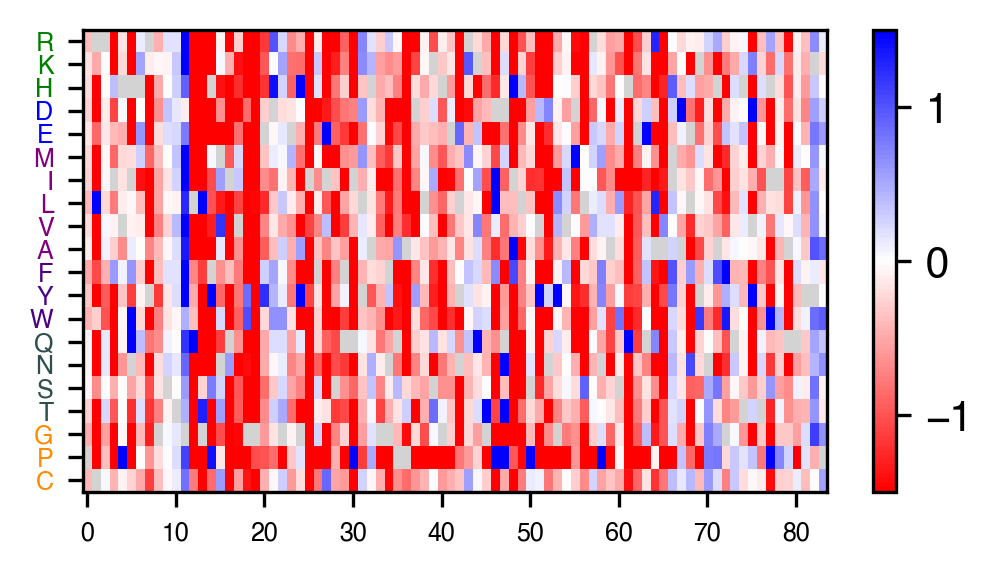

In [462]:
lim = max(np.abs(binding_data.min().min()), np.abs(binding_data.max().max()))
lim = 1.5
fig, ax1 = plt.subplots(1, 1, figsize=(4, 2))
im1 = ax1.imshow(binding_data.drop(columns=[-1]).to_numpy() * -1, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
ax1.set_yticks(range(len(binding_data.index)), binding_data.index)  # Label x-axis with column names
# ax1.set_xticks(np.arange(kernel_size, step=2))

# This is to color the amino acid labels
for ytic in ax1.get_yticklabels():
    if ytic.get_text() in colors.keys(): 
        ytic.set_color(colors[ytic.get_text()])
ax1.tick_params(axis='both', which='major', labelsize=6) 

plt.colorbar(im1)

In [354]:
na_mask = np.isnan(binding_data.drop(columns=[-1]).to_numpy())

NameError: name 'custom_cmap' is not defined

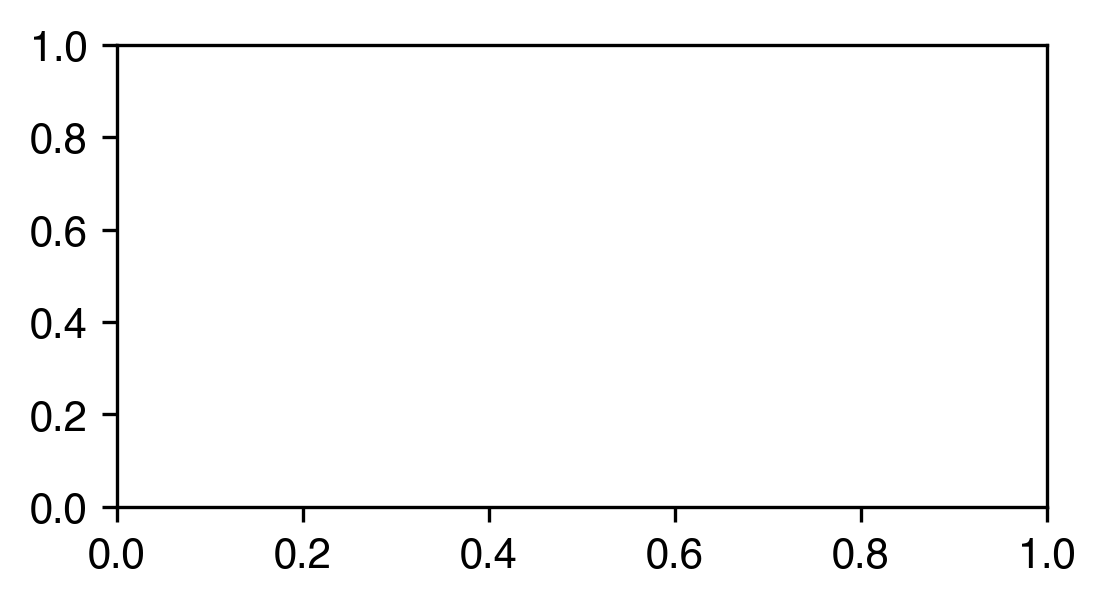

In [56]:
conv_weights = get_conv_weights(two_state_biophysical_model, layer='conv1.weight')
na_mask = np.isnan(binding_data.drop(columns=[-1]).to_numpy())
lim = max(np.abs(conv_weights.min().min()), np.abs(conv_weights.max().max()))
# lim = max(np.abs(binding_data.min().min()), np.abs(binding_data.max().max()))

plotting_weights = np.where(~na_mask, conv_weights.T.to_numpy(), np.nan)
# plotting_weights = conv_weights.T.to_numpy()

fig, ax1 = plt.subplots(1, 1, figsize=(4, 2))

custom_cmap.set_bad('lightgrey',1.)
# plt.imshow(plotting_weights, interpolation='nearest', cmap=cmap, aspect='auto',vmin=-lim,vmax=lim)

im1 = ax1.imshow(plotting_weights, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
ax1.set_yticks(range(len(conv_weights.T.index)), conv_weights.T.index)  # Label x-axis with column names
# ax1.set_xticks(np.arange(kernel_size, step=2))

# This is to color the amino acid labels
for ytic in ax1.get_yticklabels():
    if ytic.get_text() in colors.keys(): 
        ytic.set_color(colors[ytic.get_text()])
ax1.tick_params(axis='both', which='major', labelsize=6) 

plt.colorbar(im1)

# plt.savefig('figures/PSD95_params.pdf', dpi=1000, bbox_inches='tight')


In [402]:
binding_data

location,-1,1,2,3,4,5,6,7,8,9,...,75,76,77,78,79,80,81,82,83,84
new_AA,,,,,,,,,,,,,,,,,,,,,
R,NaN,0.370323,NaN,NaN,13.100070,0.173837,10.171382,-0.102692,NaN,0.458996,...,-0.031392,5.921921,0.374562,-0.516132,0.356801,1.426425,0.071959,0.368608,-0.669184,-0.102641
K,NaN,0.174262,0.489344,-0.005348,11.797765,0.224682,2.101803,-0.518722,0.100347,0.042381,...,-0.228000,-0.742479,0.250433,0.864459,-0.222078,0.818353,0.119374,0.479456,NaN,0.228555
H,NaN,0.193818,1.604199,0.025672,-0.382579,NaN,NaN,NaN,2.244313,0.505107,...,NaN,12.374048,-0.203695,NaN,0.186476,1.008269,0.119496,0.572007,-0.314119,-0.013428
D,NaN,0.249725,8.109577,0.090386,1.105517,-0.050589,1.633381,0.015000,3.551467,0.650361,...,-0.007527,-1.675261,0.609808,1.932364,0.098288,0.850947,0.176886,0.708488,-0.569682,-0.279805
E,NaN,0.148840,0.892137,0.125688,0.393471,0.454945,12.892948,-0.625743,2.086352,0.191013,...,-0.356257,7.813445,0.055162,3.531645,0.063523,12.506283,-0.009124,0.420711,-0.796726,-0.580585
M,NaN,0.220037,1.820763,0.035143,0.882732,0.234038,0.199049,-0.290113,0.878029,0.376745,...,0.093395,2.181201,0.264822,0.455422,0.057705,1.668980,-0.119855,0.019132,-0.628371,-0.032009
I,NaN,0.260819,2.882712,0.050098,NaN,0.152601,NaN,1.397893,3.242674,0.530942,...,0.171632,0.462812,1.015137,NaN,NaN,1.094470,0.330718,0.953823,-0.484436,0.090967
L,NaN,0.395434,-2.536392,0.234799,0.754709,0.098981,0.033010,0.377312,1.480736,0.536469,...,-0.157342,1.815318,0.459021,0.167604,0.184019,1.091431,-0.079347,0.623744,-0.649861,-0.020703
V,NaN,0.204833,1.898792,-0.058408,0.083065,NaN,0.069788,0.113946,2.031525,0.740445,...,-0.113722,NaN,-0.075411,0.808165,-0.140269,0.053422,-0.188098,0.425626,-0.656007,-0.032127


In [436]:
pd.DataFrame([binding_data[i+1], conv_weights.loc[i].T]).T.dropna()

,84,83
R,-0.102641,0.124883
K,0.228555,0.220209
H,-0.013428,0.245731
D,-0.279805,-0.028275
E,-0.580585,0.276183
M,-0.032009,-0.210672
I,0.090967,0.143574
L,-0.020703,0.129765
V,-0.032127,0.163914
A,-0.857302,0.265357


In [438]:
lim = max(np.abs(binding_data.min().min()), np.abs(binding_data.max().max()))

for i in range(84):
    # fig, ax1 = plt.subplots(1, 1, figsize=(1, 2))
    plotting_data = pd.DataFrame([binding_data[i+1], conv_weights.loc[i].T]).T.dropna().to_numpy()#.reshape(1, -1)

    # im1 = ax1.imshow(plotting_data.T, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    # ax1.set_yticks(range(len(binding_data.index)), binding_data.index)  # Label x-axis with column names
    # # ax1.set_xticks(np.arange(kernel_size, step=2))

    # # This is to color the amino acid labels
    # for ytic in ax1.get_yticklabels():
    #     if ytic.get_text() in colors.keys(): 
    #         ytic.set_color(colors[ytic.get_text()])
    # ax1.tick_params(axis='both', which='major', labelsize=6) 

    # plt.colorbar(im1)
    # plt.show()
    print(pearsonr(plotting_data[:,0], plotting_data[:,1]))

PearsonRResult(statistic=-0.10480800680290821, pvalue=0.6693705752864747)
PearsonRResult(statistic=-0.019612215152970264, pvalue=0.9384319260730114)
PearsonRResult(statistic=-0.585014739541174, pvalue=0.008511300541347943)
PearsonRResult(statistic=-0.5467080251684541, pvalue=0.015428170334197928)
PearsonRResult(statistic=0.42661443060839177, pvalue=0.07747306459368562)
PearsonRResult(statistic=-0.18020921012971367, pvalue=0.48885849260197367)
PearsonRResult(statistic=-0.35389391208377996, pvalue=0.13715713851122668)
PearsonRResult(statistic=-0.29332482960968365, pvalue=0.23746797371398334)
PearsonRResult(statistic=-0.21301221882600382, pvalue=0.3812608877540103)
PearsonRResult(statistic=-0.24725346015251407, pvalue=0.3074708410139314)
PearsonRResult(statistic=0.021069174373162396, pvalue=0.9317744249826316)
PearsonRResult(statistic=0.6494584215179219, pvalue=0.002618700165571106)
PearsonRResult(statistic=-0.49510940712591905, pvalue=0.03113608729653944)
PearsonRResult(statistic=0.31050

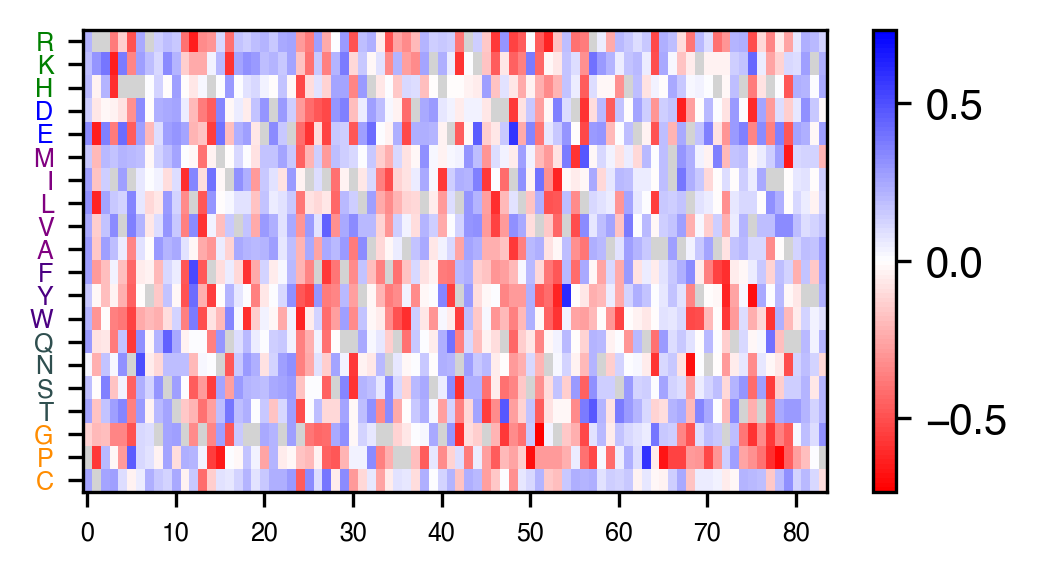

In [417]:
conv_weights = get_conv_weights(two_state_biophysical_model, layer='conv2.weight')
na_mask = np.isnan(binding_data.drop(columns=[-1]).to_numpy())
lim = max(np.abs(conv_weights.min().min()), np.abs(conv_weights.max().max()))

plotting_weights = np.where(~na_mask, conv_weights.T.to_numpy(), np.nan)
# plotting_weights = conv_weights.T.to_numpy()

fig, ax1 = plt.subplots(1, 1, figsize=(4, 2))

custom_cmap.set_bad('lightgrey',1.)
# plt.imshow(plotting_weights, interpolation='nearest', cmap=cmap, aspect='auto',vmin=-lim,vmax=lim)

im1 = ax1.imshow(plotting_weights, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
ax1.set_yticks(range(len(conv_weights.T.index)), conv_weights.T.index)  # Label x-axis with column names
# ax1.set_xticks(np.arange(kernel_size, step=2))

# This is to color the amino acid labels
for ytic in ax1.get_yticklabels():
    if ytic.get_text() in colors.keys(): 
        ytic.set_color(colors[ytic.get_text()])
ax1.tick_params(axis='both', which='major', labelsize=6) 

plt.colorbar(im1)

PearsonRResult(statistic=0.4309684367053407, pvalue=6.977151420956646e-72)
SignificanceResult(statistic=0.7018467118085635, pvalue=7.98582954711747e-233)


Text(0.5, 0, 'Ours')

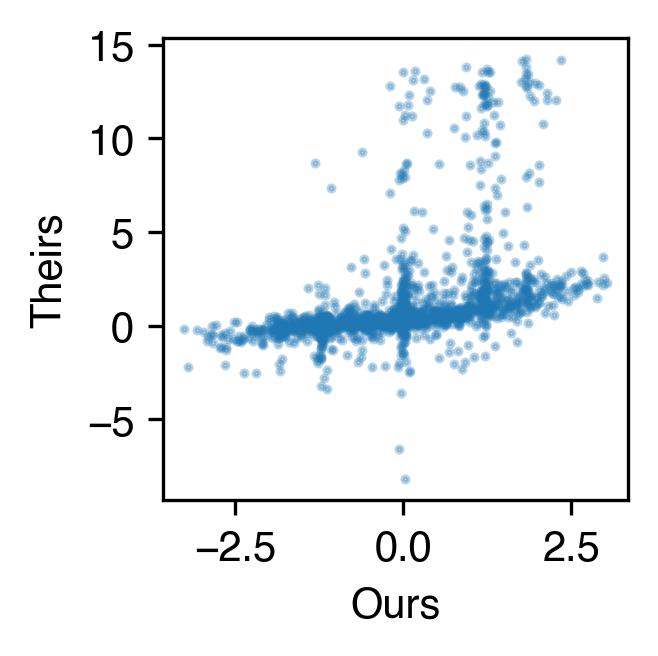

In [375]:
conv_weights = get_conv_weights(two_state_biophysical_model, layer='conv1.weight')

our_weights = conv_weights.T.values.flatten()
their_weights = binding_data.drop(columns=[-1]).values.flatten()

df = pd.DataFrame({'ours' : our_weights, 'theirs' : their_weights}).dropna()
# df = df[df['ours'] > 0]

print(pearsonr(df['theirs'], df['ours']))
print(spearmanr(df['theirs'], df['ours']))

plt.figure(figsize=(2, 2))
plt.scatter(df['ours'], df['theirs'], s=2, alpha=0.3)
plt.ylabel("Theirs")
plt.xlabel("Ours")
# plt.ylim(-5, 5)

PearsonRResult(statistic=-0.6913607027840984, pvalue=5.359987946844254e-226)
SignificanceResult(statistic=-0.8452646440087966, pvalue=0.0)


Text(0.5, 0, 'Ours')

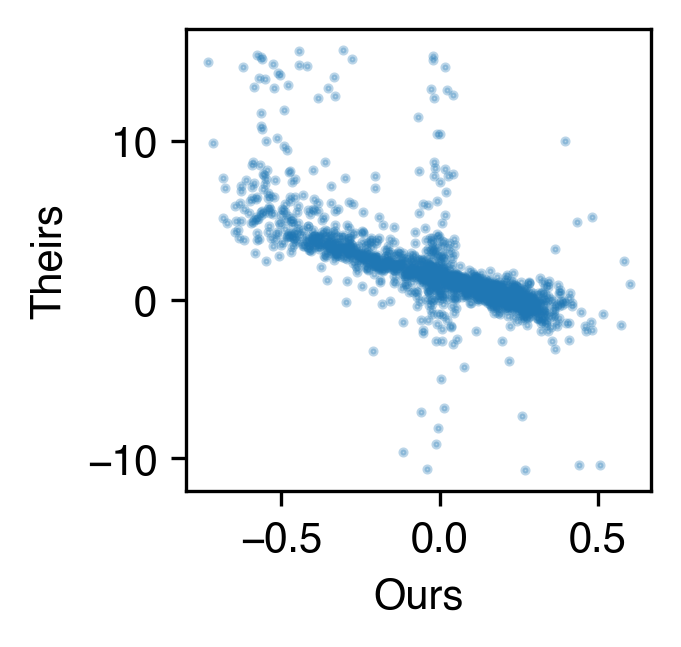

In [372]:
conv_weights = get_conv_weights(two_state_biophysical_model, layer='conv2.weight')

our_weights = conv_weights.T.values.flatten()
their_weights = folding_data.drop(columns=[-1]).values.flatten()

df = pd.DataFrame({'ours' : our_weights, 'theirs' : their_weights}).dropna()
# df = df[df['ours'] > 0]

print(pearsonr(df['theirs'], df['ours']))
print(spearmanr(df['theirs'], df['ours']))

plt.figure(figsize=(2, 2))
plt.scatter(df['ours'], df['theirs'], s=2, alpha=0.3)
plt.ylabel("Theirs")
plt.xlabel("Ours")
# plt.ylim(-5, 5)

In [483]:
confidence_filtered = inferred_delta_G[inferred_delta_G['b_ddg_pred_conf']].pivot(columns="Pos", index='Mut', values='b_dg_pred').loc[amino_acids]
confidence_filtered.drop(columns=[np.nan])

Pos,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,...,75.0,76.0,77.0,78.0,79.0,80.0,81.0,82.0,83.0,84.0
Mut,,,,,,,,,,,,,,,,,,,,,
R,-0.528678,NaN,NaN,7.471033,-0.616560,NaN,-0.735249,NaN,-0.383819,-0.777271,...,-0.732619,NaN,-0.529574,NaN,-0.525590,-0.124883,-0.674139,-0.470287,-1.091875,-0.777027
K,-0.649104,-0.383075,-0.740036,NaN,-0.526000,NaN,-0.831105,-0.684816,-0.594816,-0.681987,...,-0.816613,NaN,-0.562914,NaN,-0.666467,-0.256645,-0.645280,-0.240713,NaN,-0.543281
H,-0.696557,0.396665,-0.717508,NaN,NaN,NaN,NaN,0.886170,-0.414852,-0.706370,...,NaN,NaN,-0.741211,NaN,-0.633875,NaN,-0.367259,-0.350333,-0.877981,-0.795655
D,-0.564490,NaN,-0.574500,NaN,-0.561068,NaN,-0.770319,NaN,-0.346174,-1.000766,...,-0.781197,NaN,-0.303843,NaN,-0.650840,0.035217,-0.675041,-0.257679,-0.971476,-0.923877
E,-0.733387,NaN,-0.632045,0.267814,-0.448329,NaN,-0.996673,NaN,-0.557555,-0.490647,...,-0.903452,NaN,-0.699552,NaN,-0.674710,NaN,-0.758100,-0.444869,-1.172541,-0.982959
M,-0.586617,0.141764,-0.740838,NaN,-0.591876,-0.633502,-0.852083,0.155914,-0.437598,-0.664654,...,-0.627277,NaN,-0.498232,-0.604066,-0.665355,NaN,-0.799101,-0.592952,-1.177591,-0.877813
I,-0.566825,NaN,-0.640891,NaN,-0.552304,NaN,-0.173876,NaN,-0.485688,-0.602402,...,-0.563840,-0.362346,-0.120325,NaN,NaN,-0.098589,-0.538158,-0.127293,-0.983010,-0.683646
L,-0.448618,NaN,-0.528231,-0.292799,-0.664548,-0.678193,-0.458410,0.163679,-0.092755,-0.686360,...,-0.779240,0.268611,-0.435170,-0.659122,-0.595073,-0.067600,-0.716837,-0.333282,-1.204942,-0.714920
V,-0.620955,0.377091,-0.767912,-0.640058,NaN,-0.597357,-0.561950,0.338910,-0.343986,-0.627572,...,-0.760320,NaN,-0.741942,-0.323409,-0.792198,-0.709403,-0.779656,-0.495692,-1.083585,-0.735957


PearsonRResult(statistic=0.5096677708147497, pvalue=4.677457031197346e-80)
SignificanceResult(statistic=0.7556864622058075, pvalue=1.0574145767546513e-221)


Text(0.5, 0, 'Ours')

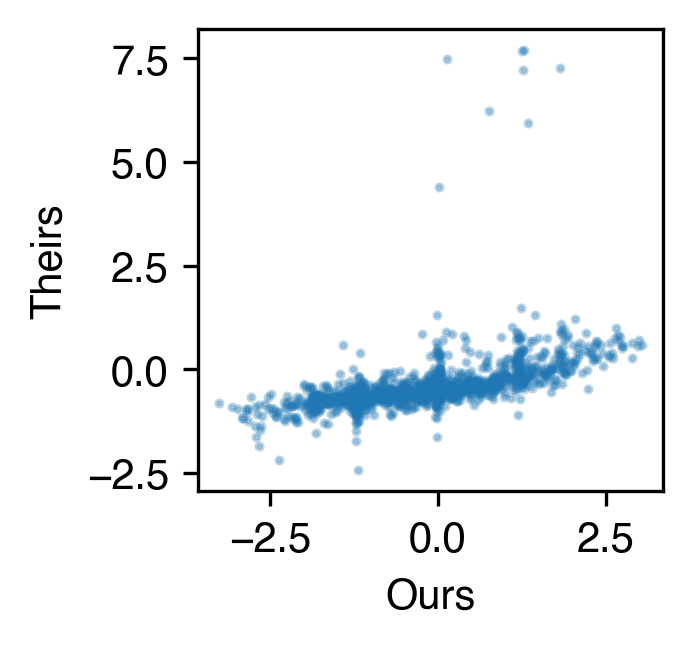

In [484]:
conv_weights = get_conv_weights(two_state_biophysical_model, layer='conv1.weight')

our_weights = conv_weights.T.values.flatten()
their_weights = confidence_filtered.drop(columns=[np.nan]).values.flatten()

df = pd.DataFrame({'ours' : our_weights, 'theirs' : their_weights}).dropna()
# df = df[df['ours'] > 0]

print(pearsonr(df['theirs'], df['ours']))
print(spearmanr(df['theirs'], df['ours']))

plt.figure(figsize=(2, 2))
plt.scatter(df['ours'], df['theirs'], s=2, alpha=0.3)
plt.ylabel("Theirs")
plt.xlabel("Ours")
# plt.ylim(-5, 5)

In [502]:
get_linear_weights(two_state_biophysical_model, layer='linear1.weight') 

array([[-1.561]], dtype=float32)

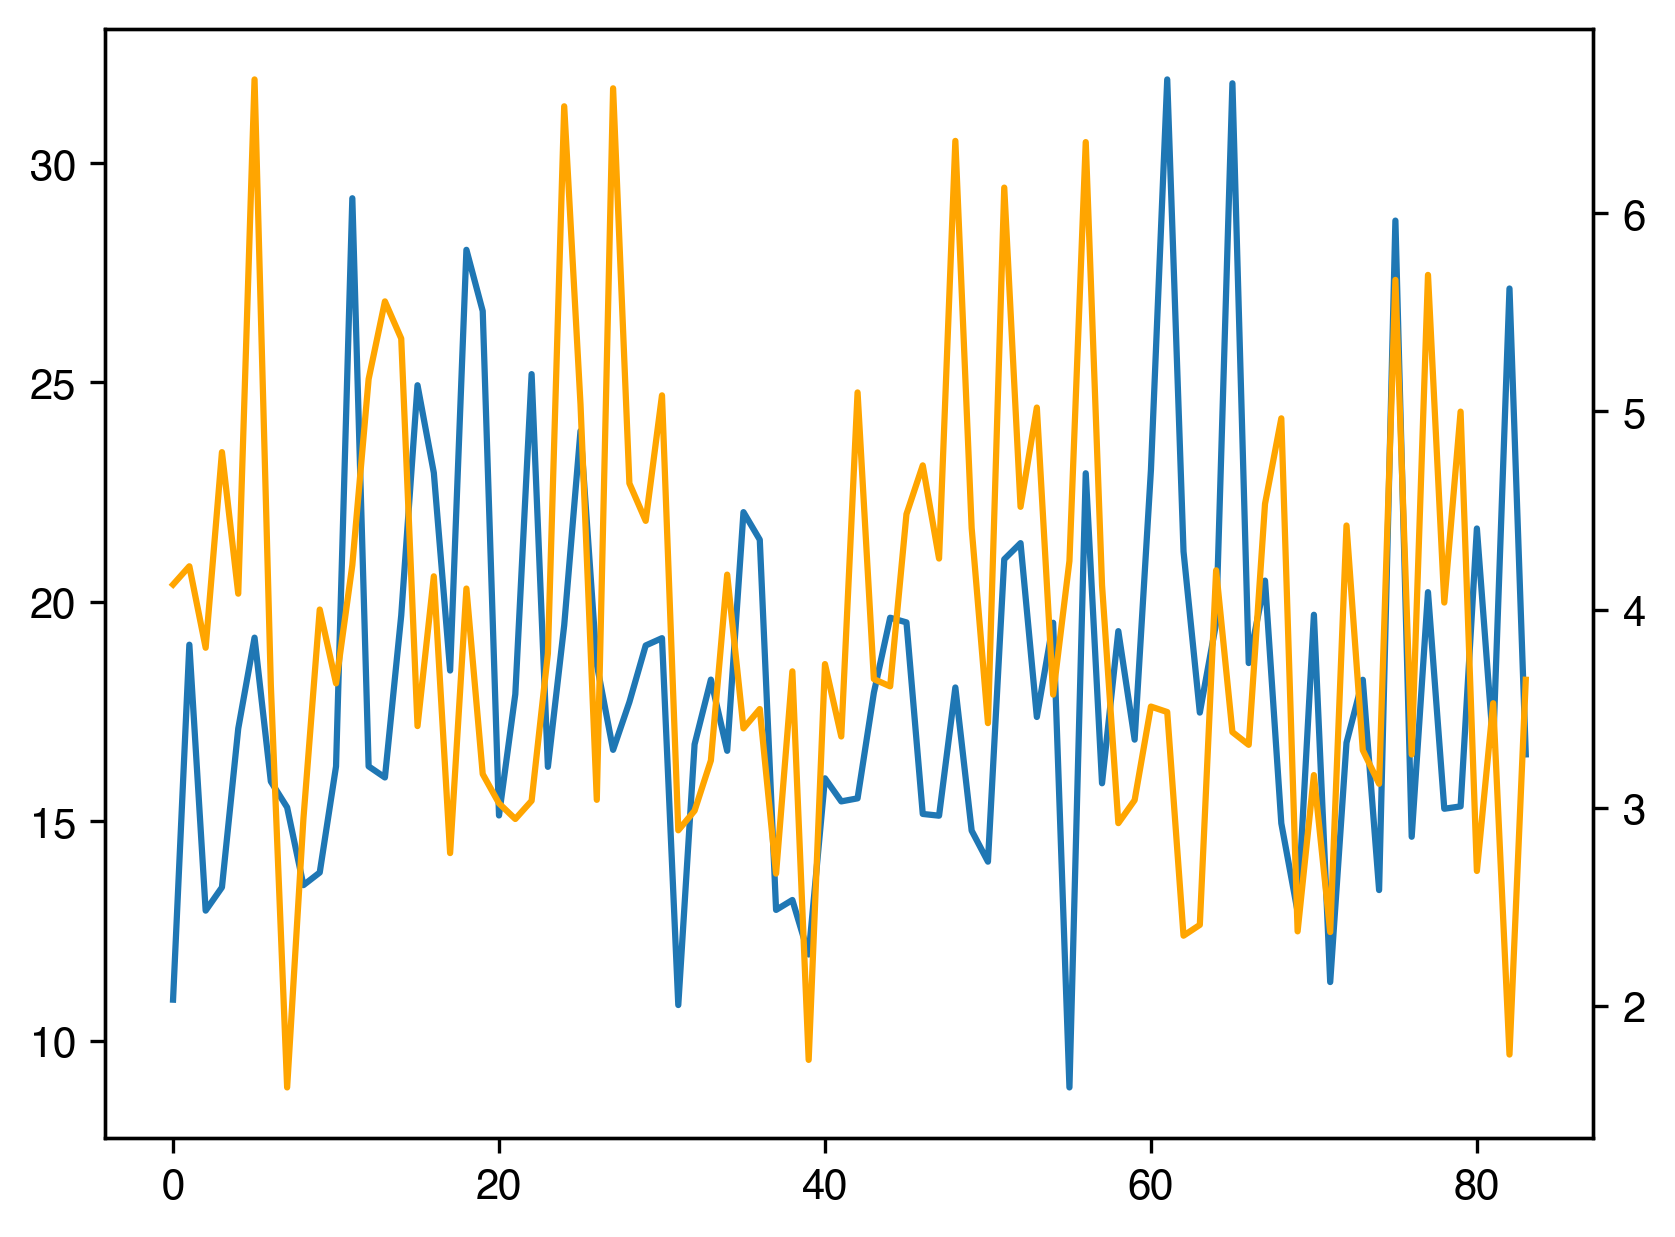

In [16]:
fig, ax1 = plt.subplots()
conv_weights_1 = get_conv_weights(two_state_biophysical_model, layer='conv1.weight')
ax1.plot(np.abs(conv_weights_1).sum(axis=1))


conv_weights_2 = get_conv_weights(two_state_biophysical_model, layer='conv2.weight')
ax2 = ax1.twinx()
ax2.plot(np.abs(conv_weights_2).sum(axis=1), color='orange')


# 11-15
# plt.vlines(11, 10, 30, color='black')
# plt.vlines(15, 10, 30, color='black')
# plt.vlines(18, 10, 30, color='black')
# plt.vlines(26, 10, 30, color='black')
# plt.vlines(59, 10, 30, color='black')
# plt.vlines(63, 10, 30, color='black')
# plt.vlines(66, 10, 30, color='black')
# plt.vlines(67, 10, 30, color='black')

In [17]:
WT_seq

'PRRIVIHRGSTGLGFNIVGGEDGEGIFISFILAGGPADLSGELRKGDQILSVNGVDLRNASHEQAAIALKNAGQTVTIIAQYKP'

In [ ]:
pos_0 = 311
allosteric_pos_1 = 312-pos_0
allosteric_pos_2 = 

1

In [27]:
322 - pos_0

11

In [75]:
binding_positions = [61, 65, 68, 69, 11, 12, 13, 14, 15, 16, 17, 28]
allostery_positions = [1, 7, 18, 19, 25, 46, 62, 64]

In [45]:
ranked_weights = (conv_weights_1.sum(axis=1)).sort_values(ascending=False).reset_index()
ranked_weights[[a in binding_positions for a in ranked_weights['index']]]
ranked_weights[[a in allostery_positions for a in ranked_weights['index']]]

,index,0
1,18,26.014191
2,19,24.485794
4,25,22.017921
9,62,15.259345
17,7,10.576128
19,1,10.111956
20,46,9.836949
24,64,7.847434


In [104]:
ligand_dist.columns

Index(['Pos_ref', 'id', 'id_ref', 'Pos', 'mut_order', 'f_dg_pred',
       'f_ddg_pred', 'f_ddg_pred_sd', 'b_dg_pred', 'b_ddg_pred',
       'b_ddg_pred_sd', 'f_ddg_pred_conf', 'b_ddg_pred_conf', 'HAmin_ligand',
       'scHAmin_ligand', 'RSASA', 'SS', 'Pos_class', 'protein', 'WT_AA', 'Mut',
       'b_ddg_wposmeanabs', 'b_ddg_wposse', 'allosteric', 'orthosteric',
       'allosteric_mutation'],
      dtype='object')

In [131]:
ligand_dist = pd.read_excel("/Users/claireleblanc/Downloads/41586_2022_4586_MOESM10_ESM.xlsx", sheet_name="TableS7")
filtered_ligand_dist = ligand_dist[ligand_dist['protein'] == 'PSD95-PDZ3'][["Pos_ref", 'HAmin_ligand']]

filtered_ligand_dist = filtered_ligand_dist.drop_duplicates().dropna().reset_index(drop=True)
filtered_ligand_dist['pos'] = filtered_ligand_dist["Pos_ref"] - 311

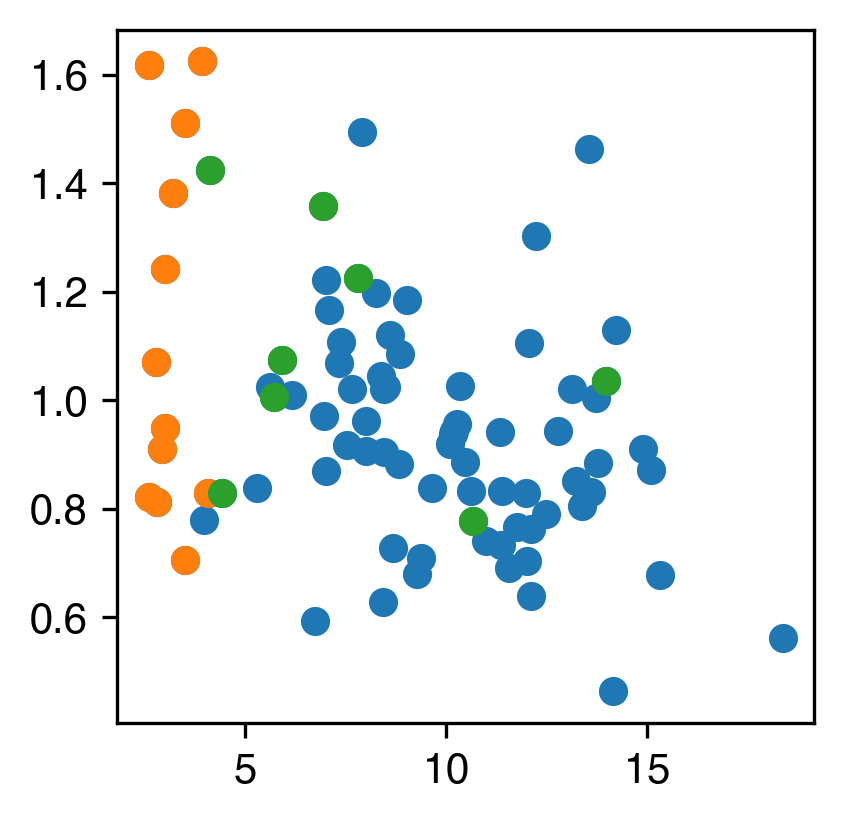

In [139]:
plt.figure(figsize=(3,3))
weight_mean = pd.DataFrame(np.nanmean(np.abs(np.where(~na_mask, conv_weights_1.T.to_numpy(), np.nan)), axis=0))

merged_dist_weight = filtered_ligand_dist.merge(weight_mean, left_on='pos', right_index=True)

plt.scatter(merged_dist_weight['HAmin_ligand'], merged_dist_weight[0])

plt.scatter(merged_dist_weight[[a in binding_positions for a in weight_mean.index]]['HAmin_ligand'], merged_dist_weight[[a in binding_positions for a in weight_mean.index]][0])
plt.scatter(merged_dist_weight[[a in allostery_positions for a in weight_mean.index]]['HAmin_ligand'], merged_dist_weight[[a in allostery_positions for a in weight_mean.index]][0])


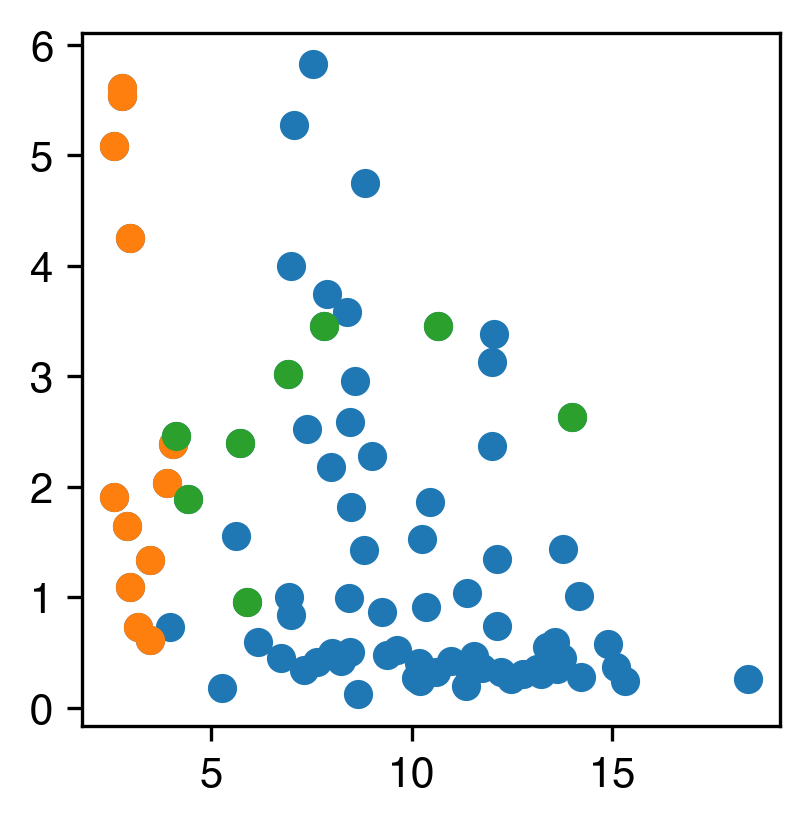

In [ ]:
# For their data
plt.figure(figsize=(3,3))
merged_dist_weight = pd.DataFrame(np.nanmean(np.abs(binding_data.drop(columns=[-1])), axis=0)).merge(filtered_ligand_dist, left_index=True, right_on='pos')

plt.scatter(merged_dist_weight['HAmin_ligand'], merged_dist_weight[0])

plt.scatter(merged_dist_weight[[a in binding_positions for a in weight_mean.index]]['HAmin_ligand'], merged_dist_weight[[a in binding_positions for a in weight_mean.index]][0])
plt.scatter(merged_dist_weight[[a in allostery_positions for a in weight_mean.index]]['HAmin_ligand'], merged_dist_weight[[a in allostery_positions for a in weight_mean.index]][0])


In [165]:
binding_data

location,-1,1,2,3,4,5,6,7,8,9,...,75,76,77,78,79,80,81,82,83,84
new_AA,,,,,,,,,,,,,,,,,,,,,
R,NaN,0.370323,NaN,NaN,13.100070,0.173837,10.171382,-0.102692,NaN,0.458996,...,-0.031392,5.921921,0.374562,-0.516132,0.356801,1.426425,0.071959,0.368608,-0.669184,-0.102641
K,NaN,0.174262,0.489344,-0.005348,11.797765,0.224682,2.101803,-0.518722,0.100347,0.042381,...,-0.228000,-0.742479,0.250433,0.864459,-0.222078,0.818353,0.119374,0.479456,NaN,0.228555
H,NaN,0.193818,1.604199,0.025672,-0.382579,NaN,NaN,NaN,2.244313,0.505107,...,NaN,12.374048,-0.203695,NaN,0.186476,1.008269,0.119496,0.572007,-0.314119,-0.013428
D,NaN,0.249725,8.109577,0.090386,1.105517,-0.050589,1.633381,0.015000,3.551467,0.650361,...,-0.007527,-1.675261,0.609808,1.932364,0.098288,0.850947,0.176886,0.708488,-0.569682,-0.279805
E,NaN,0.148840,0.892137,0.125688,0.393471,0.454945,12.892948,-0.625743,2.086352,0.191013,...,-0.356257,7.813445,0.055162,3.531645,0.063523,12.506283,-0.009124,0.420711,-0.796726,-0.580585
M,NaN,0.220037,1.820763,0.035143,0.882732,0.234038,0.199049,-0.290113,0.878029,0.376745,...,0.093395,2.181201,0.264822,0.455422,0.057705,1.668980,-0.119855,0.019132,-0.628371,-0.032009
I,NaN,0.260819,2.882712,0.050098,NaN,0.152601,NaN,1.397893,3.242674,0.530942,...,0.171632,0.462812,1.015137,NaN,NaN,1.094470,0.330718,0.953823,-0.484436,0.090967
L,NaN,0.395434,-2.536392,0.234799,0.754709,0.098981,0.033010,0.377312,1.480736,0.536469,...,-0.157342,1.815318,0.459021,0.167604,0.184019,1.091431,-0.079347,0.623744,-0.649861,-0.020703
V,NaN,0.204833,1.898792,-0.058408,0.083065,NaN,0.069788,0.113946,2.031525,0.740445,...,-0.113722,NaN,-0.075411,0.808165,-0.140269,0.053422,-0.188098,0.425626,-0.656007,-0.032127


SignificanceResult(statistic=0.3116735850966893, pvalue=0.0039018553089103262)

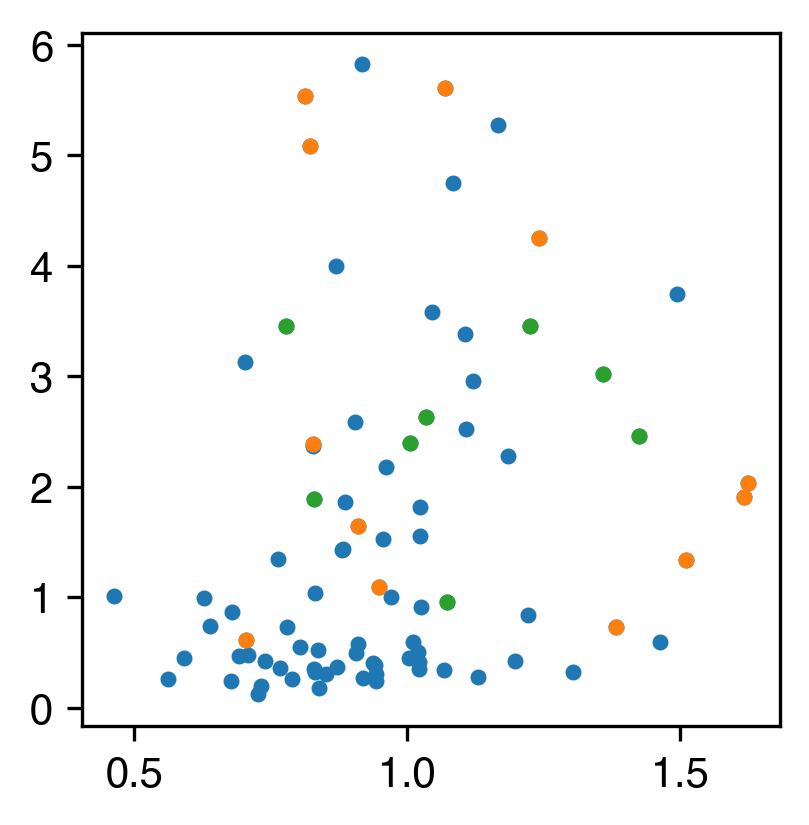

In [164]:
# For their data
plt.figure(figsize=(3,3))
weight_mean_us = pd.DataFrame(np.nanmean(np.abs(np.where(~na_mask, conv_weights_1.T.to_numpy(), np.nan)), axis=0))

weight_mean_them = pd.DataFrame(np.nanmean(np.abs(binding_data.drop(columns=[-1])), axis=0))

plt.scatter(weight_mean_us[0], weight_mean_them[0], s=8)

plt.scatter(weight_mean_us[[a in binding_positions for a in weight_mean.index]][0], weight_mean_them[[a in binding_positions for a in weight_mean.index]][0], s=8)
plt.scatter(weight_mean_us[[a in allostery_positions for a in weight_mean.index]][0], weight_mean_them[[a in allostery_positions for a in weight_mean.index]][0], s=8)

pearsonr(weight_mean_us[0], weight_mean_them[0])

spearmanr(weight_mean_us[0], weight_mean_them[0])


<BarContainer object of 12 artists>

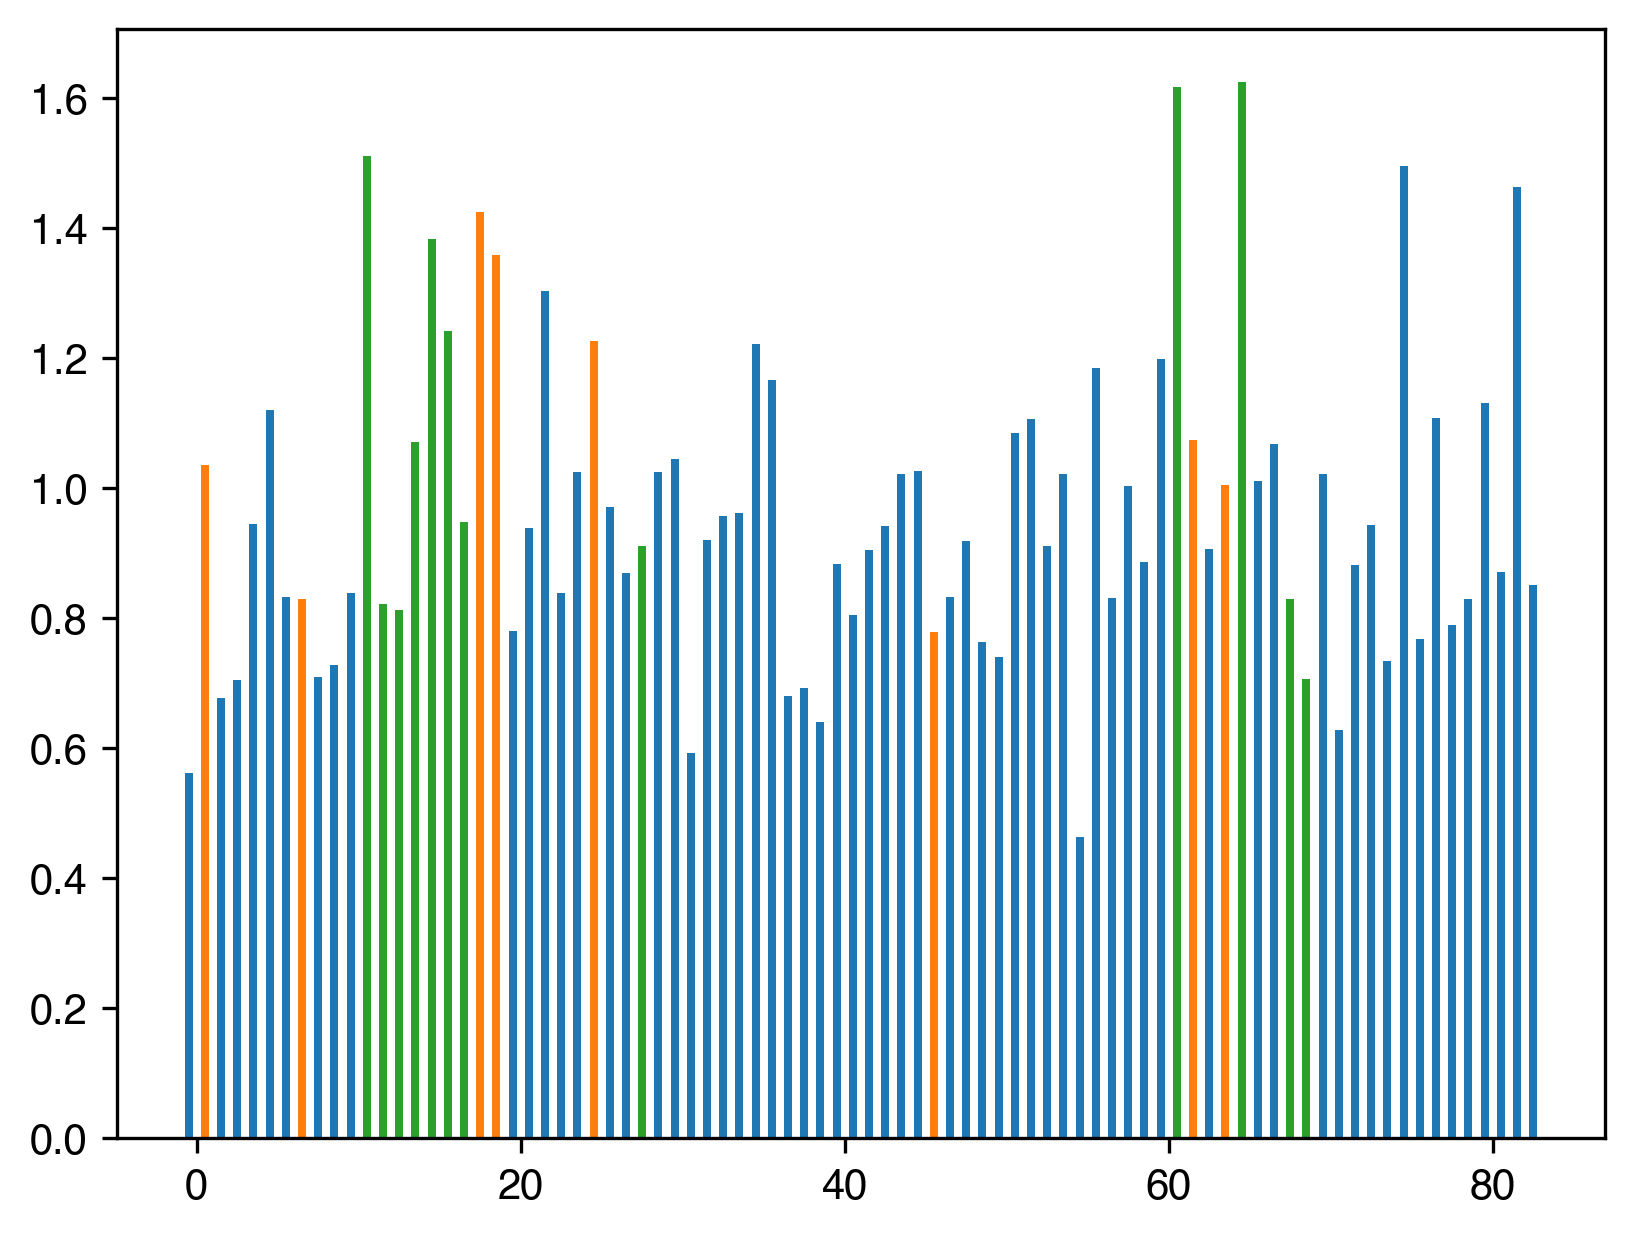

In [99]:
# mean absolute change in binding free energy greater than that of mutations in the binding interface
# How they defined their allosteric sites

weight_mean = pd.DataFrame(np.nanmean(np.abs(np.where(~na_mask, conv_weights_1.T.to_numpy(), np.nan)), axis=0))

plt.bar(x= weight_mean.index - 0.5, height=weight_mean[0], width=0.5)
plt.bar(x= weight_mean[[a in allostery_positions for a in weight_mean.index]].index -0.5, height=weight_mean[[a in allostery_positions for a in weight_mean.index]][0], width=0.5)
plt.bar(x= weight_mean[[a in binding_positions for a in weight_mean.index]].index -0.5 , height=weight_mean[[a in binding_positions for a in weight_mean.index]][0], width=0.5)


Text(0.5, 0, 'Weight position')

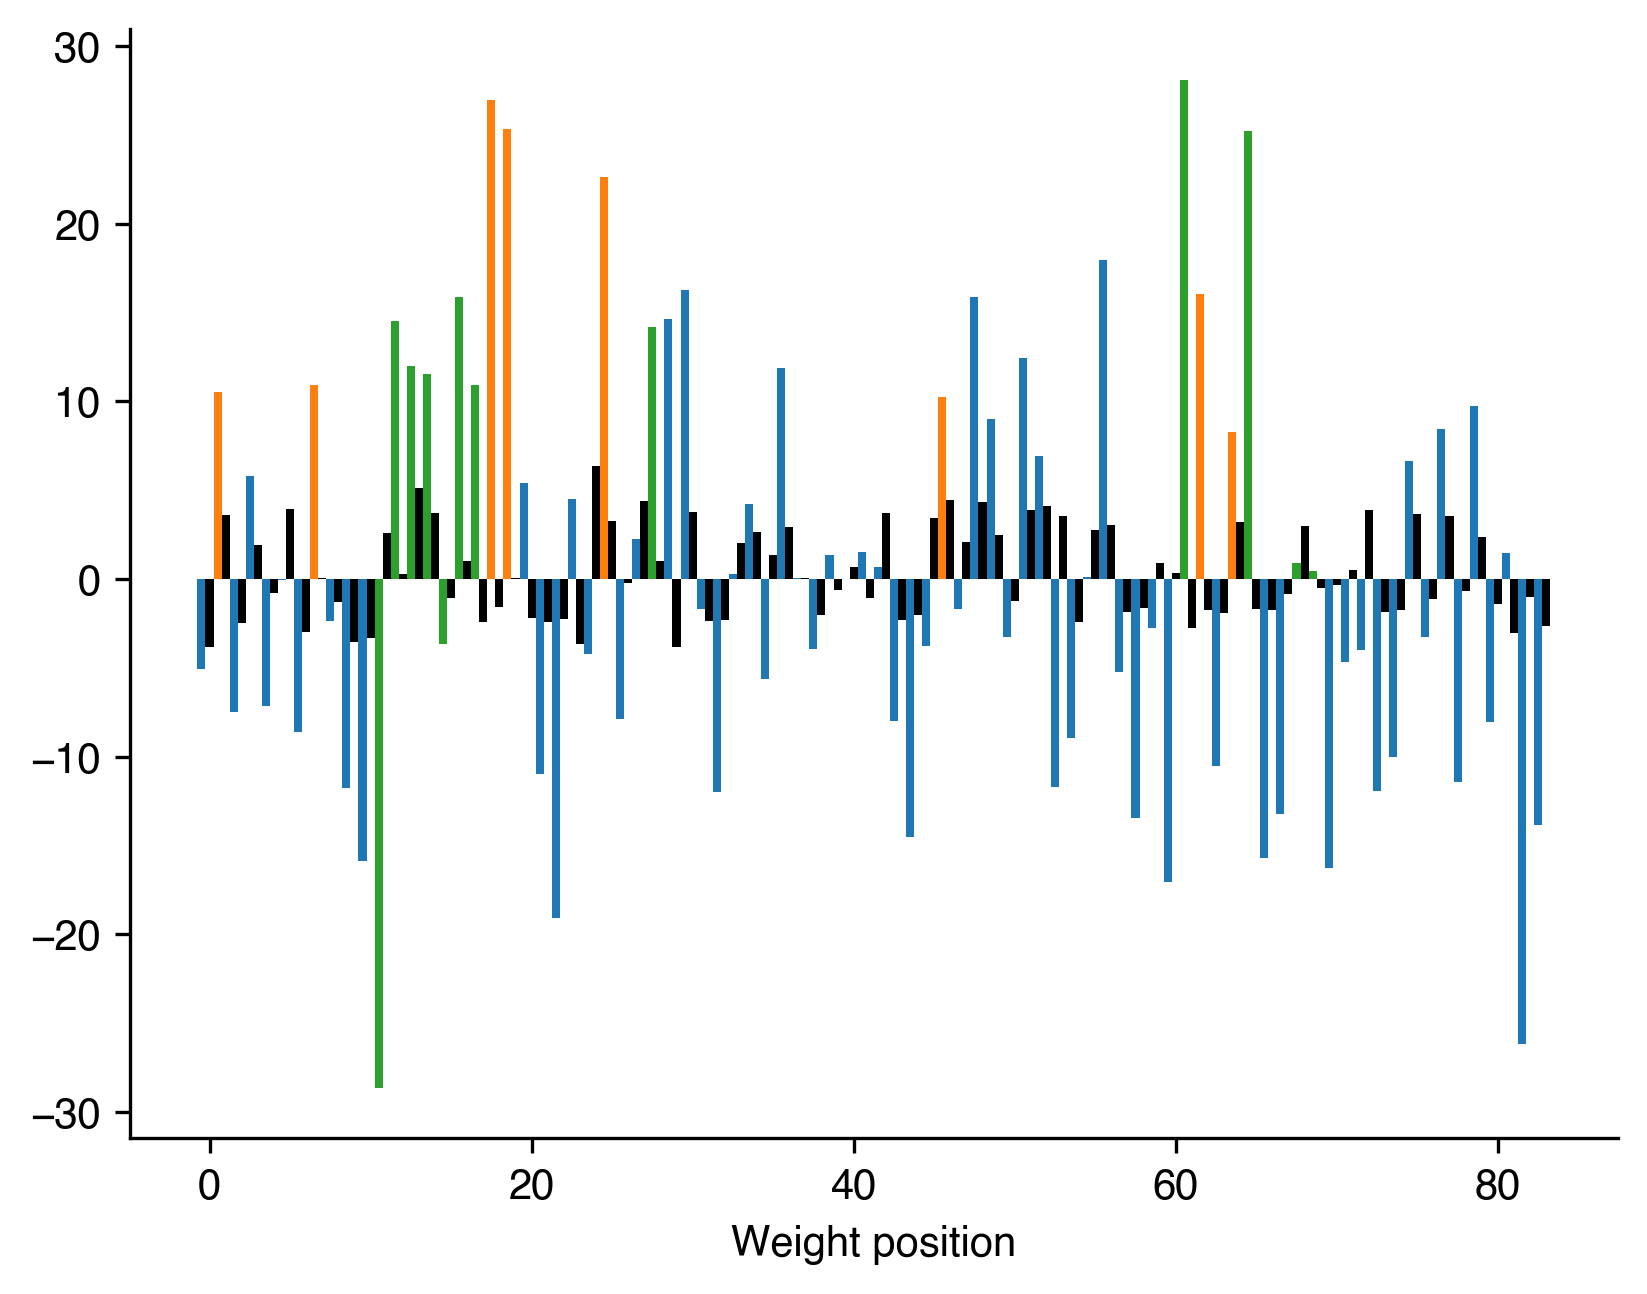

In [83]:
weight_sum = pd.DataFrame(np.nansum(np.where(~na_mask, conv_weights_1.T.to_numpy(), np.nan), axis=0))

plt.bar(x= weight_sum.index - 0.5, height=weight_sum[0], width=0.5)
plt.bar(x= weight_sum[[a in allostery_positions for a in weight_sum.index]].index -0.5, height=weight_sum[[a in allostery_positions for a in weight_sum.index]][0], width=0.5)
plt.bar(x= weight_sum[[a in binding_positions for a in weight_sum.index]].index -0.5 , height=weight_sum[[a in binding_positions for a in weight_sum.index]][0], width=0.5)

weight_sum = pd.DataFrame(np.nansum(np.where(~na_mask, conv_weights_2.T.to_numpy(), np.nan), axis=0))
plt.bar(x= weight_sum.index, height=weight_sum[0] * -1, width=0.5, color='black')

sns.despine()

plt.xlabel("Weight position")

In [93]:
weight_sum

location
1      4.915336
2     42.299692
3      3.182112
4     57.441957
5      1.087429
        ...    
80    42.189157
81     3.740462
82     6.161058
83    -9.804494
84    -4.382009
Length: 84, dtype: float64

Text(0.5, 0, 'Weight position')

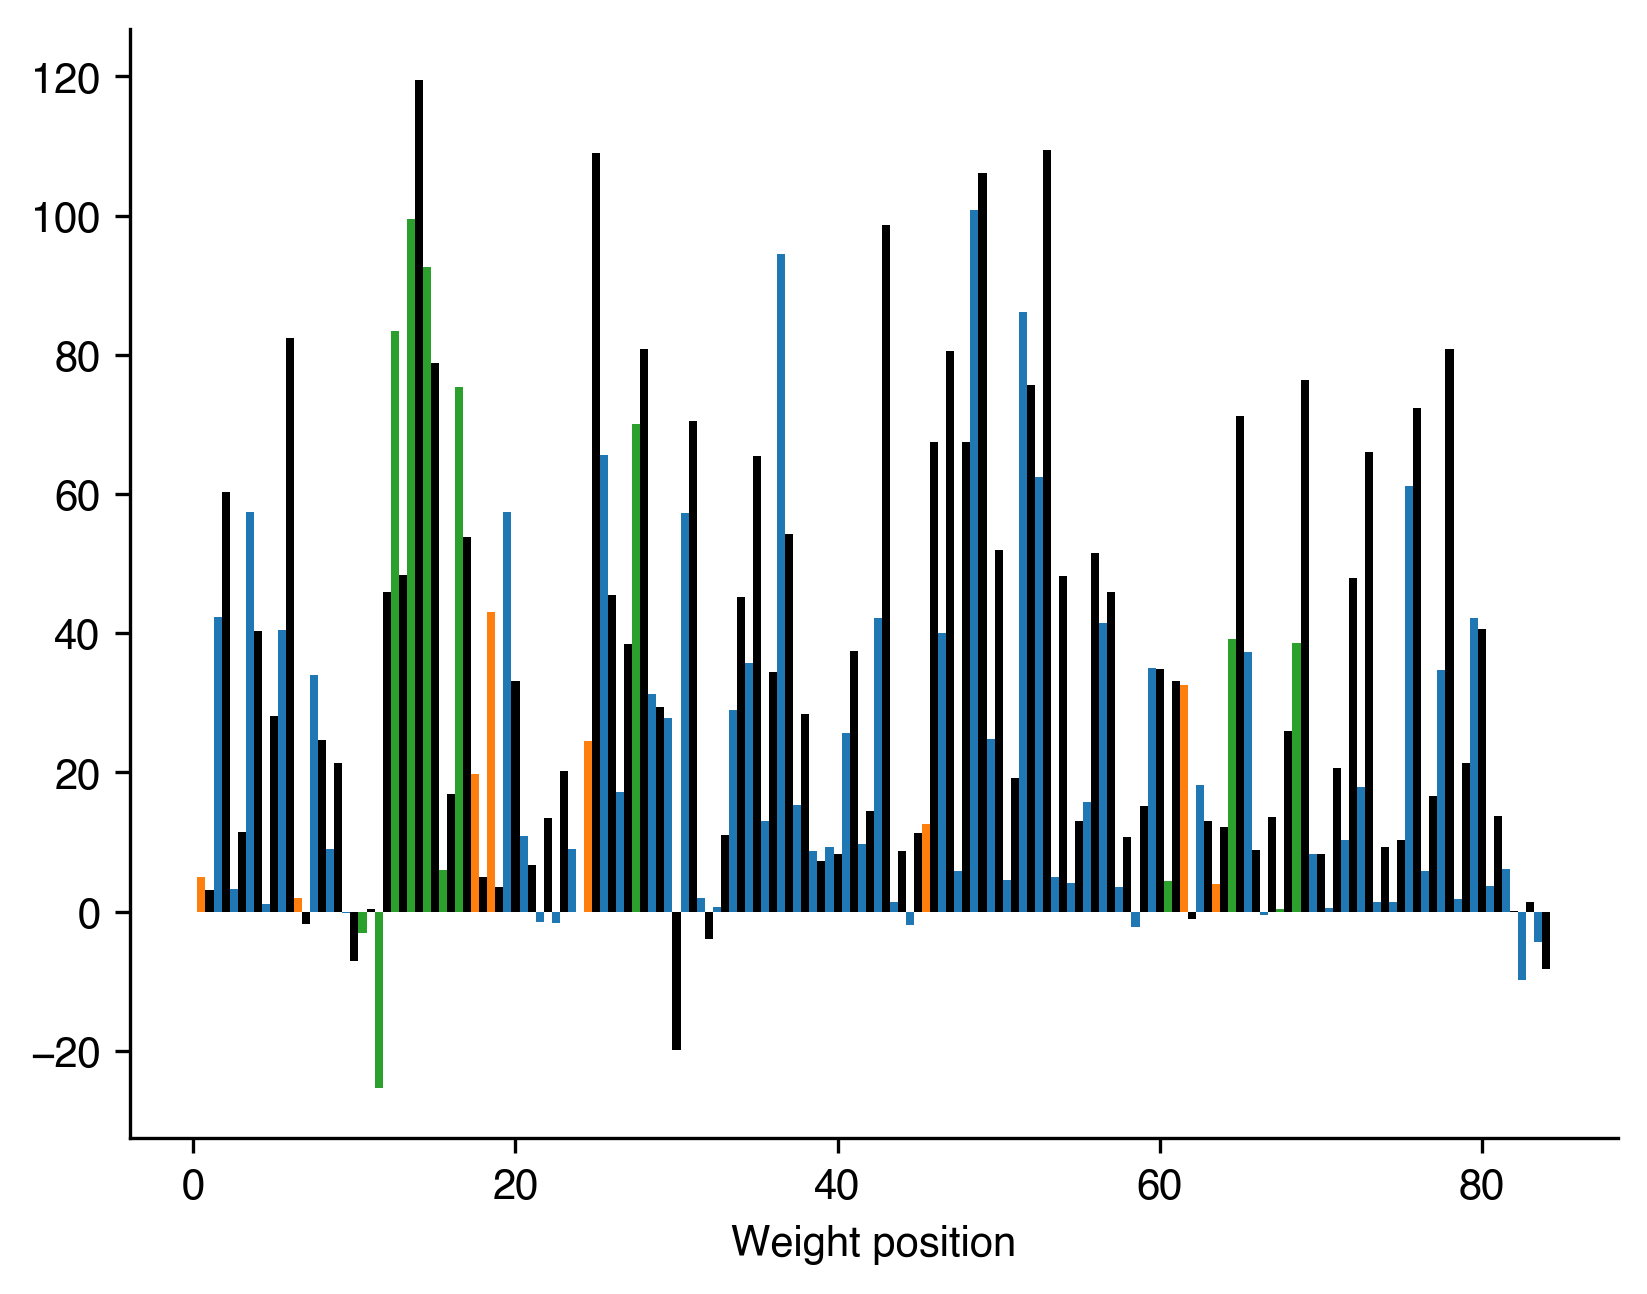

In [95]:
weight_sum = binding_data.drop(columns=[-1]).sum(axis=0)

plt.bar(x= weight_sum.index - 0.5, height=weight_sum, width=0.5)
plt.bar(x= weight_sum[[a in allostery_positions for a in weight_sum.index]].index -0.5, height=weight_sum[[a in allostery_positions for a in weight_sum.index]], width=0.5)
plt.bar(x= weight_sum[[a in binding_positions for a in weight_sum.index]].index -0.5 , height=weight_sum[[a in binding_positions for a in weight_sum.index]], width=0.5)

weight_sum = folding_data.drop(columns=[-1]).sum(axis=0)
plt.bar(x= weight_sum.index, height=weight_sum, width=0.5, color='black')

sns.despine()

plt.xlabel("Weight position")

# Random code

In [166]:
import tensorflow as tf

model_dir = "/Users/claireleblanc/Downloads/Data/mochi/GRB2-SH3/mochi__fit_tmodel_3state_sparse_dimsum128/whole_model/my_model_0/"
loaded = tf.saved_model.load(model_dir)

In [167]:
keras_model = tf.keras.models.load_model(model_dir)
keras_model.summary()

Model: "functional_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_fold (InputLayer)        [(None, 1057)]       0           []                               
                                                                                                  
 input_bind (InputLayer)        [(None, 757)]        0           []                               
                                                                                                  
 folding_additivetrait (Dense)  (None, 1)            1057        ['input_fold[0][0]']             
                                                                                                  
 binding_additivetrait (Dense)  (None, 1)            757         ['input_bind[0][0]']             
                                                                                       

In [168]:
additive_weights = keras_model.get_layer('folding_additivetrait').get_weights()
binding_additive_weights = keras_model.get_layer('binding_additivetrait').get_weights()

In [169]:
keras_model.get_layer('state_prob_bound').get_weights()

[]

In [170]:
params['NN_weights_folding'] = additive_weights[0]
params['NN_weights_binding'] = binding_additive_weights[0]
params

ValueError: Length of values (757) does not match length of index (1057)

# Seed correlations

In [418]:
def get_mean_weights(model_list, layer_num=1): 
    """
    Takes a list of models and averages their weights (should all have the same filter size).
    Averages models with positive and negative linear weights separately.

    Parameters 
    ----------
    model_list : list
        list of NNs 

    layer_num : int
        Which layer of the NN we are interested in

    Returns 
    -------
    mean_conv_array : np.array
        Mean of the convolutional weights for the given models
        which had positive linear weights
    mean_linear_array : np.array
        Mean of the linear weights for the given models
        which had poitive linear weights
    mean_conv_array_neg : np.array
        Mean of the convolutional weights for the given models
        which had negative linear weights
    mean_linear_array_neg : np.array
        Mean of the linear weights for the given models
        which had negative linear weights
    """
    conv_weights = []
    linear_weight_ls = []
    conv_array_neg = []
    linear_array_neg = []
    
    # Get the weights for each model
    for model in model_list:
        linear_weights = get_linear_weights(model, f"linear{layer_num}.weight")
        # Separate weights by positive and negative 
        if (linear_weights.sum() < 0):
            conv_array_neg.append(get_conv_weights(model, f"conv{layer_num}.weight").values)
            linear_array_neg.append(linear_weights)
        else: 
            conv_weight = get_conv_weights(model, f"conv{layer_num}.weight").values
            linear_weight_ls.append(linear_weights)
            conv_weights.append(conv_weight)

    # Average convolutional weights
    stacked_arrays = np.stack(conv_weights, axis=0)
    mean_conv_array = np.mean(stacked_arrays, axis=0)

    # Average positive linear weights
    stacked_arrays = np.stack(linear_weight_ls, axis=0)
    mean_linear_array = np.mean(linear_weight_ls, axis=0)

    # Average negative linear weights (if they exist)
    if len(conv_array_neg) > 0:
        stacked_arrays = np.stack(conv_array_neg, axis=0)
        mean_conv_array_neg = np.mean(stacked_arrays, axis=0)
        stacked_arrays = np.stack(linear_array_neg, axis=0)
        mean_linear_array_neg = np.mean(linear_array_neg, axis=0)
    else: 
        mean_conv_array_neg = np.array([])
        mean_linear_array_neg = np.array([])

    return mean_conv_array, mean_linear_array.flatten(), mean_conv_array_neg, mean_linear_array_neg.flatten()

def make_row_plot(fig, kernel_size, model_conv1, model_linear1, row, lim, height_ratios, num_rows, height_max=0, height_min=0):
    """
    Core functionality for creating the convolutional filter plots. 
    Plots the convolution filter as a heatmap and the linear weights as a bar plot.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object created with plt.figure
    
    kernel_size : int
        The size of the convolutional filter

    model_conv1 : np.array
        Averaged convolutional filter weights

    model_linear1 : np.array
        Averaged linear filter weights
    
    row : int
        Which row in the overall figure should we fill in

    lim : float
        The max value for the heatmap

    height_ratios : list
        Ratio of heights between rows, length should correspond to number of rows in
        gridspec object

    num_rows : list
        The number of rows in the gridspec object
    
    height_max : float
        The maximum value for the barplot

    height_min : float
        The minimum value for the barplot

    Returns
    -------
    ax1 : maplotlib.Axes object
        Contains the heatmap
    ax2 : maplotlib.Axes object
        Contains the barplot
    im1 : maplotlib.Axes.imshow object
        The heatmap
    """

    # Calculate how much of the figure the convolutional filter vs. linear weights will take up
    ratio1 = kernel_size 
    ratio2 = 40 - kernel_size + 1
    
    # GridSpec allows us to plot rows/columns with different dimensions
    # Here, we initalize the gridspec object with the total number of rows in our figure
    # But we only fill in the specific row that we are interested in
    # (When combined with many other gridspec objects, they will all line up and look good)
    gs1 = gridspec.GridSpec(2 + num_rows*2, 2, width_ratios=[ratio1, ratio2], height_ratios=height_ratios, figure=fig)
    
    # ax1 and ax2 are matplotlib axes
    ax1 = plt.subplot(gs1[row, 0])
    ax2 = plt.subplot(gs1[row, 1])

    # This is the code for plotting the convolutional filter as a heatmap
    # Min and max values of heatmap are passed by used
    im1 = ax1.imshow(model_conv1, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    ax1.set_yticks(range(len(amino_acids)), amino_acids)  # Label x-axis with column names
    ax1.set_xticks(np.arange(kernel_size, step=2))
    
    # This is to color the amino acid labels
    for ytic in ax1.get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])
    ax1.tick_params(axis='x', which='major', labelsize=15) 
    ax1.tick_params(axis='y', which='major', labelsize=8) 

    # This is the code for plotting the linear weights as a bar graph
    ax2.bar(range(len(model_linear1)), model_linear1, color="grey")
    ax2.set_ylim(height_min, height_max)
    
    ax2.spines["top"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["bottom"].set_position('zero')
    ax2.spines["bottom"].set_linewidth(2.5)
    ax2.spines['bottom'].set_bounds(-1, len(model_linear1))
    
    # Remove all x-ticks for the bargraph
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_xticklabels([])
    ax2.set_yticklabels([])

    return ax1, ax2, im1

def get_linear_weights(model, layer):
    """
    Extracts the linear weights to the NN
    and returns a numpy array
    """
    model_state_dict = model.state_dict()
    linear_weights = model_state_dict[layer].detach().numpy()
    return linear_weights


def make_multi_filter_plot_mean(models, kernel_sizes, positive=True, layer_num=1):
    """
    Generates the final figure by calling make_row_plot for each filter size
    Plots the mean params for each filter size

    Parameters
    ----------
    models : list
        List of lists of NNs (one list per each conv. filter size)
    
    kernel_sizes : list
        List of kernel sizes, should correspond to models list
    
    positive : bool
        Whether to plot positive linear weights. If False, will plot 
        negative linear weights
    
    layer_num : int
        Which layer of the NN are we interested in 
    """
    
    conv_weights = []
    linear_weights = []
    updated_kernel_sizes = []

    # Get average parameters for each model
    for k, model in zip(kernel_sizes, models): 
        if positive: 
            conv1_weights, linear1_weights, _ , _ = get_mean_weights(model, layer_num)
            conv_weights.append(conv1_weights)
            linear_weights.append(linear1_weights)
            updated_kernel_sizes.append(k)
        else: 
            _, _, conv1_weights, linear1_weights = get_mean_weights(model, layer_num)
            if len(linear1_weights) > 0: 
                conv_weights.append(conv1_weights)
                linear_weights.append(linear1_weights)
                updated_kernel_sizes.append(k)

    num_rows = len(linear_weights) 

    if num_rows == 0:
        print("No models matching parameters")
        return

    # Get heatmap range
    lim = max([abs(w) for w in np.concatenate([ls.flatten() for ls in conv_weights])])

    # Get barplot range
    height_max = max(0, max([max(ls) for ls in linear_weights]))
    height_min = min(0, min([min(ls) for ls in linear_weights]))

    # Create a figure
    fig = plt.figure(figsize=(10, 3*num_rows))

    # Add padding between rows
    height_ratios = [.01] + [3.3, .1]*num_rows + [0.1]

    # Add row plots
    ax1, ax2, im1 = make_row_plot(fig, updated_kernel_sizes[0], conv_weights[0].T, linear_weights[0], 1, lim, height_ratios, num_rows, height_max, height_min)

    ax1.set_title("Convolutional Filter", fontsize=12)
    ax2.set_title("Linear weights", fontsize=12)
    
    for i, (conv_weight, linear_weight, k) in enumerate(zip(conv_weights[1:], linear_weights[1:], updated_kernel_sizes[1:])):
        make_row_plot(fig, k, conv_weight.T, linear_weight, 3+i*2, lim, height_ratios, num_rows, height_max, height_min)

    # Add colorbar
    gs_cb = gridspec.GridSpec(2 + num_rows*2, 1, width_ratios=[1], height_ratios=height_ratios, figure=fig)
    cax1 = plt.subplot(gs_cb[-1,0])

    fig.colorbar(im1,cax=cax1, orientation='horizontal')

In [421]:
# Look at correlation between seeds
size = (1,84,20)
import torch 

def load_model(name, k, ak):
    """
    Loads ADModel_two_state_abund
    """
    model = ADModel_two_state_abund(size, "Hill", k, relu=False, abund_k=ak)
    model.load_state_dict(torch.load(f"{name}.pth"))
    return model

models = []

# Load each NN and save in a list
for index in two_model_results[(two_model_results['pearson_act_val'] > 0.7) & (two_model_results['activity_fun'] == "Hill") & (two_model_results['kernel_size'] == 84)].index:
    K = two_model_results.loc[index, "kernel_size"]
    name = two_model_results.loc[index, "model_name"].removeprefix("../../")
    ak = 84

    models.append(load_model(name, K, ak))



In [423]:
pearson_r = []
spearman_r = []
for model1 in models:
    for model2 in models: 
        our_weights = get_conv_weights(model1, "conv1.weight").T.values.flatten()
        # our_weights = conv_weights[0].T.flatten()
        # their_weights = binding_data.drop(columns=[-1]).values.flatten()
        their_weights = get_conv_weights(model2, "conv1.weight").T.values.flatten()


        df = pd.DataFrame({'ours' : our_weights, 'theirs' : their_weights}).dropna()

        print(pearsonr(df['theirs'], df['ours']).correlation, spearmanr(df['theirs'], df['ours']).correlation)
        pearson_r.append(pearsonr(df['theirs'], df['ours']).correlation)
        spearman_r.append(spearmanr(df['theirs'], df['ours']).correlation)

1.0 1.0
0.98261863 0.9805839844553719
-0.9411578 -0.9307229898091254
0.6162573 0.6194312229722708
0.6193534 0.6160155572819941
0.61890244 0.617716749373241
0.621598 0.6191629911797931
-0.60009956 -0.6106902927008447
-0.6076776 -0.6119624197105269
-0.6109263 -0.6105448338705578
0.9826186 0.9805839844553719
1.0 1.0
-0.94291043 -0.9310968359085404
0.6069112 0.611281393189674
0.6176835 0.6119212338763684
0.61730653 0.6134013121461566
0.6180645 0.6143208287903811
-0.59613717 -0.604865415151133
-0.60298777 -0.6050866124881704
-0.60996985 -0.6072363237292612
-0.9411578 -0.9307229898091254
-0.94291043 -0.9310968359085404
1.0 1.0
-0.62638336 -0.6264067806956322
-0.63321066 -0.6223013724950198
-0.6327298 -0.623763211468582
-0.6348543 -0.6258760467855284
0.6042375 0.6054824636771767
0.61577475 0.611974719277567
0.62462246 0.6176265778560316
0.6162573 0.6194312229722708
0.6069112 0.611281393189674
-0.62638336 -0.6264067806956322
1.0 1.0
0.9785888 0.9816276179033713
0.97685456 0.9810701666004193
0.

In [424]:
pearson_r = []
spearman_r = []
for model1 in models:
    our_weights = get_conv_weights(model1, "conv1.weight").T.values.flatten()
    # our_weights = conv_weights[0].T.flatten()
    their_weights = binding_data.drop(columns=[-1]).values.flatten()
    # their_weights = get_conv_weights(model2, "conv1.weight").T.values.flatten()


    df = pd.DataFrame({'ours' : our_weights, 'theirs' : their_weights}).dropna()

    print(pearsonr(df['theirs'], df['ours']).correlation, spearmanr(df['theirs'], df['ours']).correlation)
    pearson_r.append(pearsonr(df['theirs'], df['ours']).correlation)
    spearman_r.append(spearmanr(df['theirs'], df['ours']).correlation)

0.45289746818923654 0.7031895860618893
0.4309684367053407 0.7018467118085635
-0.4308325331888527 -0.6650812849547687
0.5129508282577966 0.6393117168087226
0.47527622224038385 0.6351803108556466
0.47476929350080493 0.632316565323692
0.49177322702037307 0.6422832229885258
-0.5496254503235232 -0.6719938749362974
-0.5394324961293975 -0.6714717786050083
-0.5017420373837601 -0.6464980543266606


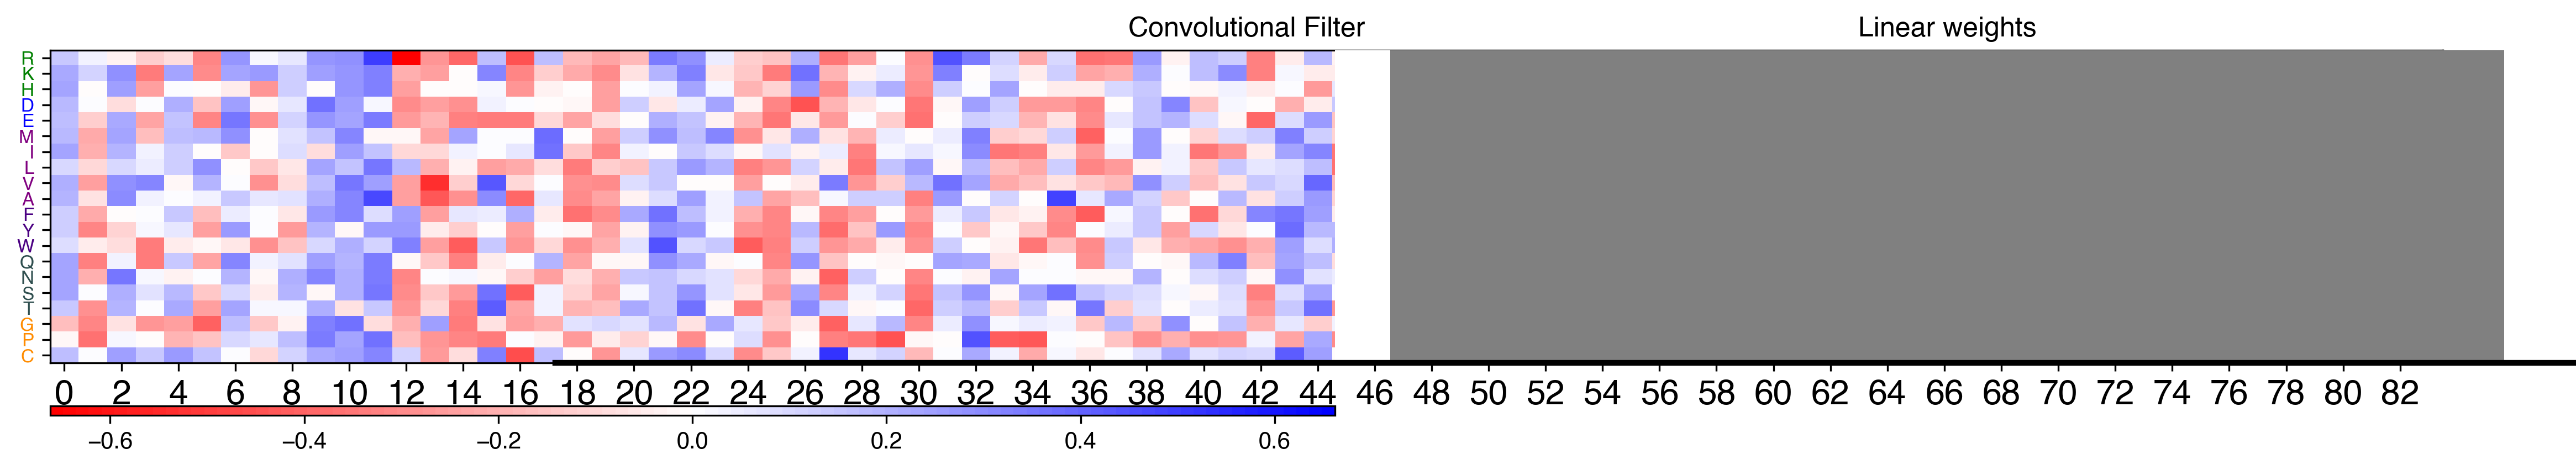

In [428]:
make_multi_filter_plot_mean([models], [84])

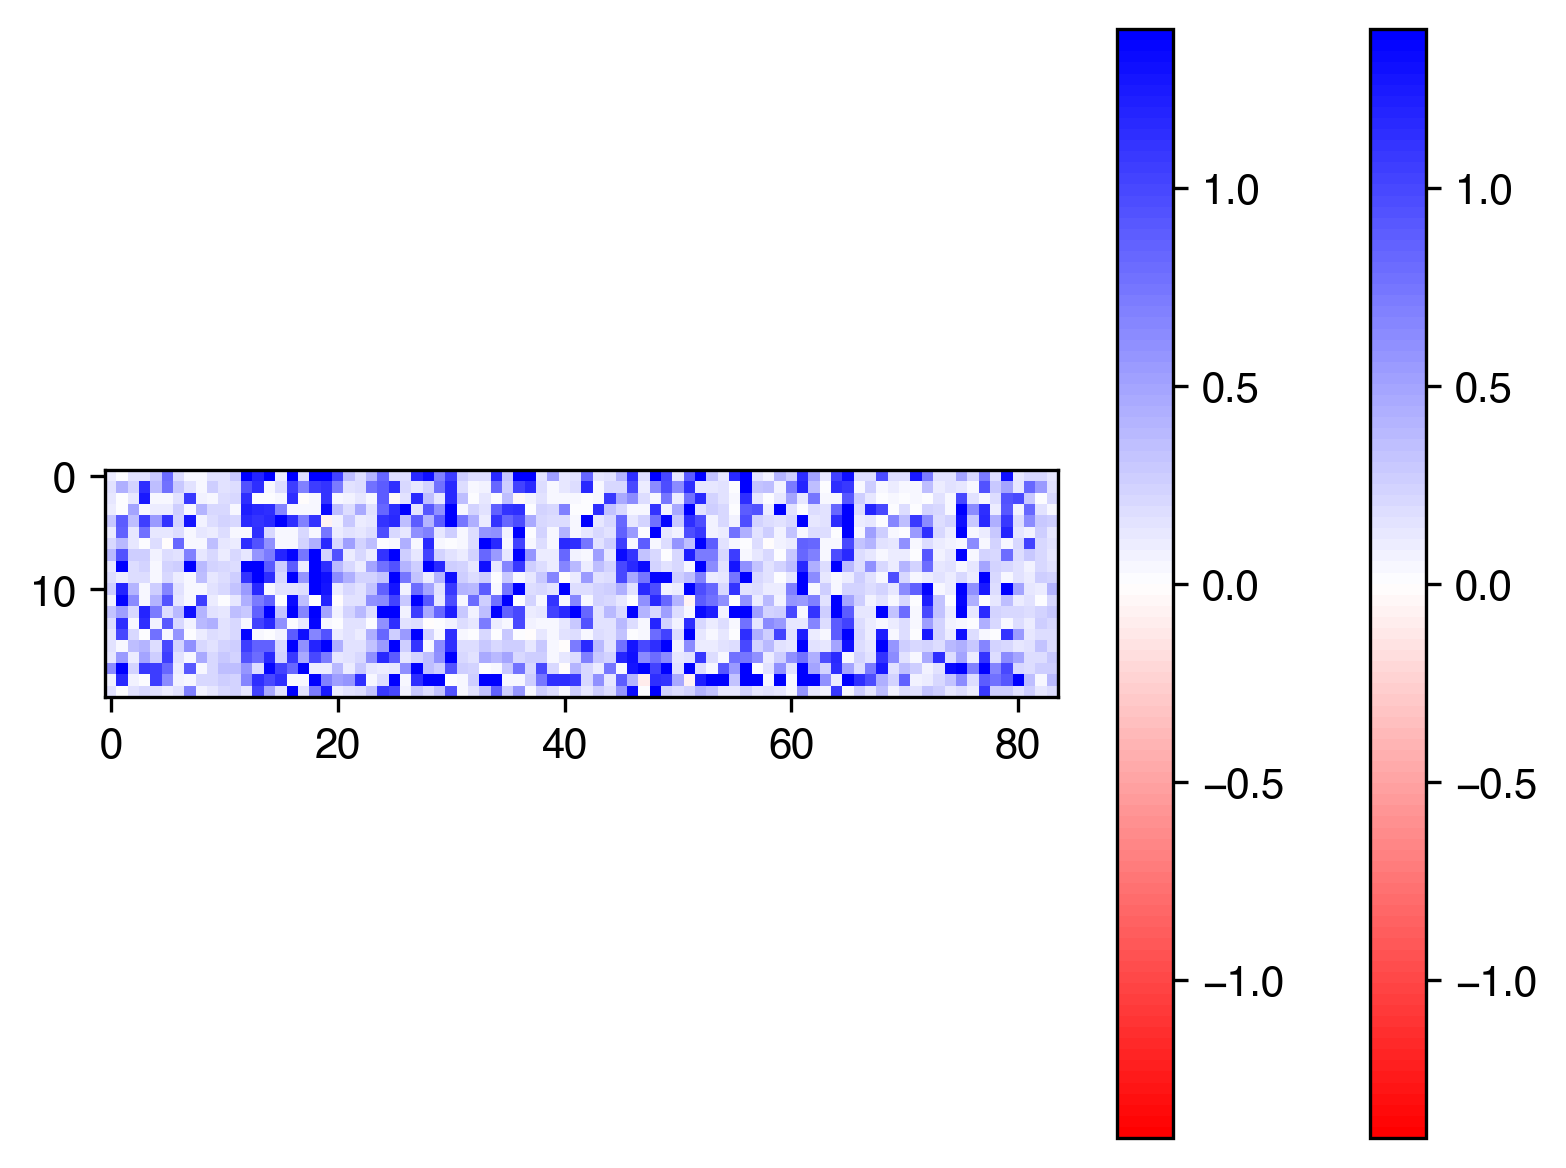

In [458]:
plt.imshow((all_weights.mean(axis=0) - weight_error).T, cmap=custom_cmap, vmin=-1.4, vmax=1.4)
plt.colorbar()

plt.imshow((all_weights.mean(axis=0) + weight_error).T, cmap=custom_cmap, vmin=-1.4, vmax=1.4)
plt.colorbar()

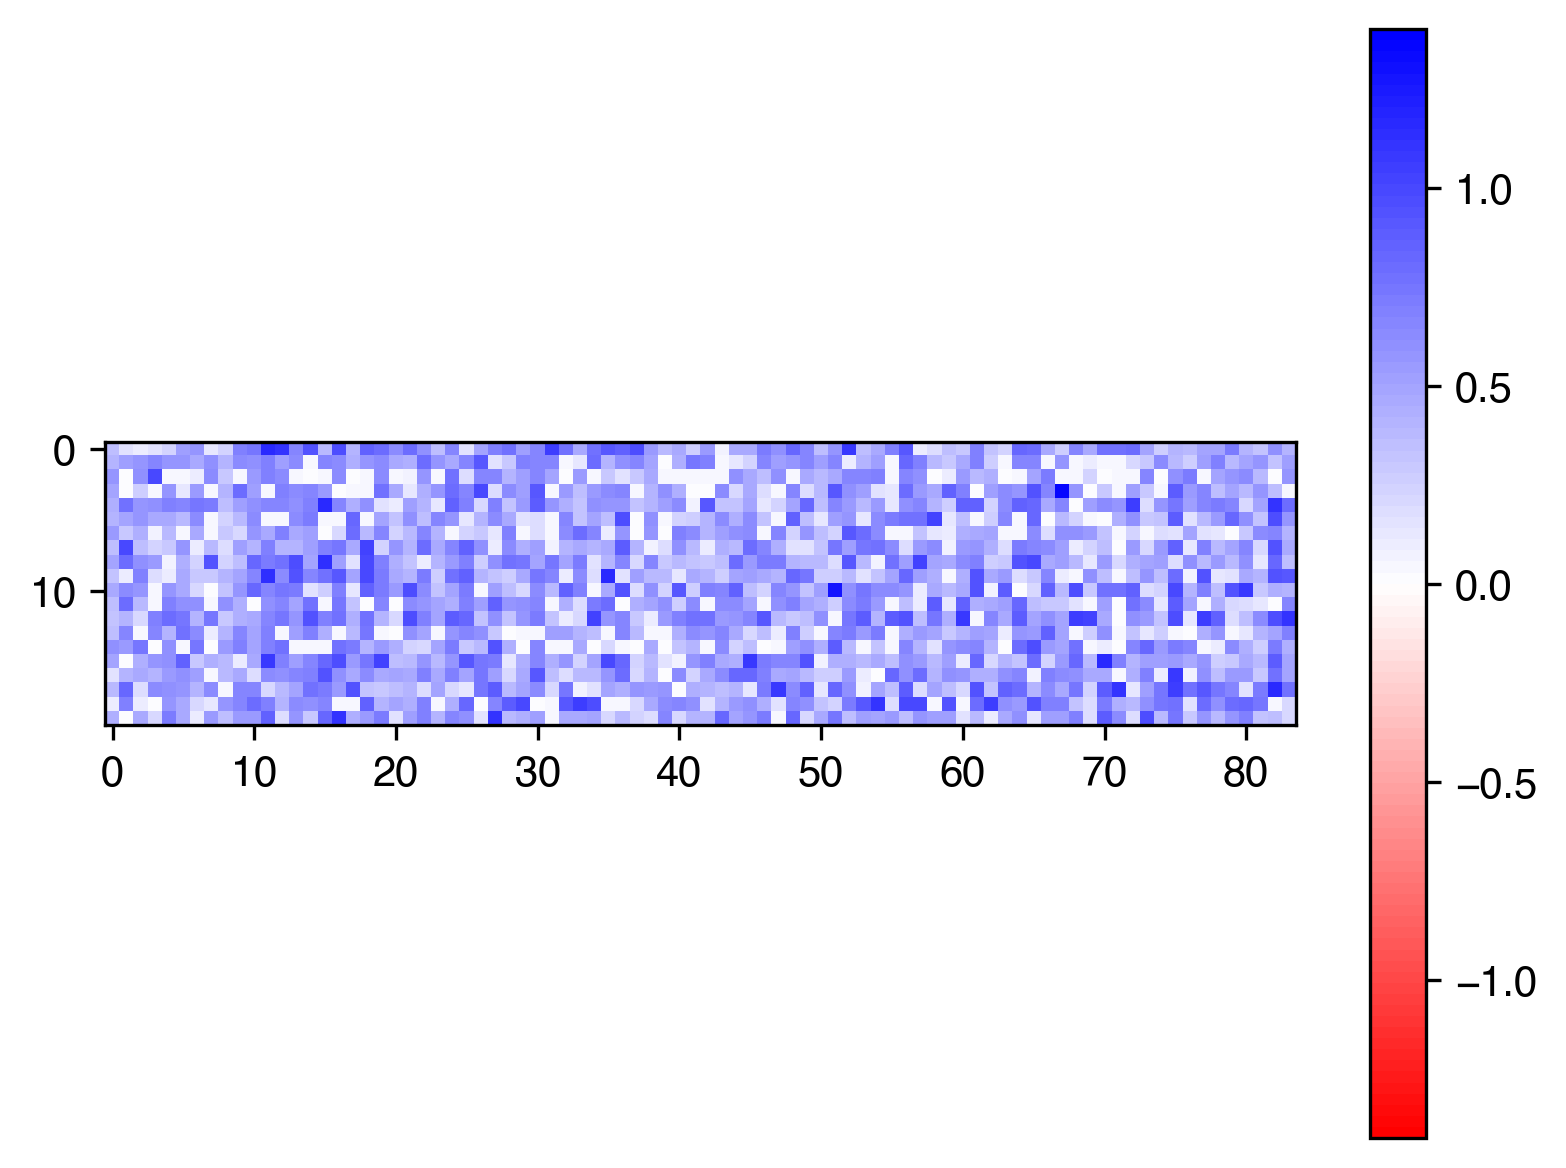

In [455]:
all_weights = np.array([get_conv_weights(model, 'conv1.weight').to_numpy() for model in models])

weight_error = all_weights.std(axis=0)

plt.imshow(weight_error.T, cmap=custom_cmap, vmin=-1.4, vmax=1.4)
plt.colorbar()